In [18]:
previous_contributions.filter(pl.col("prior_amount") >= 10000)

cmte_id,year,candidate_id,prior_amount
str,i64,str,f64
"""C00101485""",2009,"""H2TX26093""",11000.0
"""C00103549""",2007,"""H2FL03056""",22000.0
"""C00186288""",2013,"""H2IL08039""",11000.0
"""C00093179""",2015,"""H0OH12062""",22000.0
"""C00360354""",2013,"""H4AZ04024""",22000.0
…,…,…,…
"""C00264937""",2023,"""H0WA02080""",11000.0
"""C00543371""",2017,"""H2CA15094""",18000.0
"""C00477653""",2019,"""H6PA08277""",12000.0


In [17]:
import pandas as pd
import numpy as np
import polars as pl

def process_contributions(contributions: pl.DataFrame) -> pl.DataFrame:
    # Process contributions
    firm_size = (
        contributions
        .filter(pl.col("amount") > 0)
        .group_by(["cmte_id", "cycle"])
        .agg([
            pl.col("amount").sum().alias("firm_amount"),
            pl.col("cand_id").n_unique().alias("firm_candidates")
        ])
    )
    contributions= (
        contributions
        .filter(pl.col("cand_id").str.starts_with("H"))
        #.filter(pl.col("amount") > 0)
        .select([
            "cmte_id", "name", "amount", "cand_id", "rcpt_cmte", "year", "month", "day", "cycle",
            "cmte_nm", "connected_org_nm", "corporation", "ttl_receipts", "instrument", "cusip",
            "hq", "hq_state", "hq_city", "ric", "permid", "GICS_Sector", "GICS_Industry_Group",
            "GICS_Industry", "GIS_Subindustry", "TRBC_Econ_Sector", "TRBC_Business_Sector",
            "TRBC_Industry_Group", "TRBC_Industry", "TRBC_ID", "NAICS_Sector", "NAICS_Subsector",
            "NAICS_Industry_Group"
        ])
        .join(firm_size, on = ["cmte_id", "cycle"], how = "left")
    )

    return contributions


In [2]:
DATA_PATH = "s:/campaignfinance/data/"
contributions = pl.read_parquet(f"{DATA_PATH}FEC/processed/firms_principal_committees_contributions.parquet")
contribs = pl.read_parquet(f"{DATA_PATH}FEC/processed/firm_candidate_contributions.parquet")

In [3]:
df = pl.read_parquet(f"{DATA_PATH}FEC/raw/contributions/committees/candidates_2014.parquet")

In [4]:
#contribs.filter((pl.col("cmte_id") == "C00131219") & (pl.col("rcpt_cmte") == "C00543892"))
df.filter((pl.col("CMTE_ID") == "C00253153") & (pl.col("CAND_ID") == "H8FL16022"))

CMTE_ID,AMNDT_IND,RPT_TP,TRANSACTION_PGI,IMAGE_NUM,TRANSACTION_TP,ENTITY_TP,NAME,CITY,STATE,ZIP_CODE,EMPLOYER,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,OTHER_ID,CAND_ID,TRAN_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID
str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str
"""C00253153""","""A""","""YE""","""G""","""14960616594""","""24K""","""CCM""","""TOM ROONEY FOR CONGRESS""","""PUNTA GORDA""","""FL""","""33950""",null,null,"""12112013""",1000.0,"""C00432906""","""H8FL16022""","""21304434""","""915311""",null,null,"""4040820141211735458"""
"""C00253153""","""N""","""M7""","""P""","""13941191499""","""24K""","""CCM""","""TOM ROONEY FOR CONGRESS""","""PUNTA GORDA""","""FL""","""33950""",null,null,"""06062013""",2000.0,"""C00432906""","""H8FL16022""","""20938940""","""880478""",null,null,"""4081220131195257369"""


In [16]:
contributions.filter((pl.col("cmte_id") == "C00253153") & (pl.col("cand_id") == "H8FL16022") & (pl.col("year") == 2013))

cmte_id,transaction_type,election_indicator,amendment,name,city,state,zip,amount,rcpt_cmte,memo,year,month,day,cycle,cmte_nm,connected_org_nm,corporation,parent,website,ttl_receipts,instrument,cusip,isin,common_name,business_description,ric,former_name,business_name,hq,hq_state,hq_city,permid,parent_hq,parent_permid,GICS_ID,GICS_Sector,GICS_Industry_Group,GICS_Industry,GIS_Subindustry,ICB_ID,ICB_Industry,ICB_Super_Sector,ICB_Sector,ICB_Sub_Sector,Incorporation_Date,Public_Date,IPO_Date,Retire_Date,Inactive_Year,Inactive_Event,Listing_Status,TRBC_ID,TRBC_Econ_Sector,TRBC_Business_Sector,TRBC_Industry_Group,TRBC_Industry,TRBC_Activity,NAICS_ID,NAICS_Sector,NAICS_Subsector,NAICS_Industry_Group,NAICS_International_Industry,NAICS_National_Industry,index,cand_id,cmte_type
str,str,str,str,str,str,str,str,f64,str,str,i64,i64,i64,i64,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str,str,str,f64,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str
"""C00253153""","""24K""","""G""","""A""","""TOM ROONEY FOR CONGRESS""","""PUNTA GORDA""","""FL""","""33950""",1000.0,"""C00432906""",null,2013,12,11,2014,"""bloomin brands""","""bloomin brands""","""BLOOMIN BRANDS""",null,null,1.0066e6,"""BLMN.O""","""94235108""","""US0942351083""","""Bloomin' Brands Inc""","""Bloomin Brands, Inc. is a casu…","""BLMN.OQ""","""Kangaroo Hldg Inc""",null,"""United States of America""","""FLORIDA""","""Tampa""",4.2978e9,"""United States""",4.2978e9,2.530104e7,"""Consumer Discretionary""","""Consumer Services""","""Hotels, Restaurants & Leisure""","""Restaurants""",4.050104e7,"""Consumer Discretionary""","""Travel and Leisure""","""Travel and Leisure""","""Restaurants and Bars""","""10/24/2006""","""8/8/2012""","""8/8/2012""",null,null,null,"""Listed""","""['5330102010']""","""['Consumer Cyclicals']""","""['Cyclical Consumer Services']""","""['Hotels & Entertainment Servi…","""['Restaurants & Bars']""","""['Restaurants & Bars (NEC)']""","""['722511', '722410', '551112']""","""['Accommodation and Food Servi…","""['Food Services and Drinking P…","""['Restaurants and Other Eating…","""['Restaurants and Other Eating…","""['Full-Service Restaurants', '…",null,"""H8FL16022""","""P"""
"""C00253153""","""24K""","""P""","""N""","""TOM ROONEY FOR CONGRESS""","""PUNTA GORDA""","""FL""","""33950""",2000.0,"""C00432906""",null,2013,6,6,2014,"""bloomin brands""","""bloomin brands""","""BLOOMIN BRANDS""",null,null,1.0066e6,"""BLMN.O""","""94235108""","""US0942351083""","""Bloomin' Brands Inc""","""Bloomin Brands, Inc. is a casu…","""BLMN.OQ""","""Kangaroo Hldg Inc""",null,"""United States of America""","""FLORIDA""","""Tampa""",4.2978e9,"""United States""",4.2978e9,2.530104e7,"""Consumer Discretionary""","""Consumer Services""","""Hotels, Restaurants & Leisure""","""Restaurants""",4.050104e7,"""Consumer Discretionary""","""Travel and Leisure""","""Travel and Leisure""","""Restaurants and Bars""","""10/24/2006""","""8/8/2012""","""8/8/2012""",null,null,null,"""Listed""","""['5330102010']""","""['Consumer Cyclicals']""","""['Cyclical Consumer Services']""","""['Hotels & Entertainment Servi…","""['Restaurants & Bars']""","""['Restaurants & Bars (NEC)']""","""['722511', '722410', '551112']""","""['Accommodation and Food Servi…","""['Food Services and Drinking P…","""['Restaurants and Other Eating…","""['Restaurants and Other Eating…","""['Full-Service Restaurants', '…",null,"""H8FL16022""","""P"""


In [18]:
contribs = process_contributions(contributions)

In [21]:
prior = (
    contribs.
    filter(pl.col("year") % 2 == 1)
    .group_by(["cmte_id", "year", "cand_id"])
    .agg([
        pl.col("amount").sum().alias("prior_amount")
    ])
)

(array([2.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00,
        2.00000e+00, 0.00000e+00, 1.30000e+02, 3.00000e+01, 1.60000e+01,
        3.60000e+02, 2.44000e+02, 1.32000e+03, 4.36000e+02, 3.64700e+03,
        1.10474e+05, 1.13750e+04, 6.95830e+04, 1.26990e+04, 6.94400e+03,
        8.61600e+03, 2.74630e+04, 3.53500e+03, 6.81000e+02, 1.07800e+03,
        2.29200e+03, 3.38000e+02, 3.72000e+02, 3.89500e+03, 1.50000e+01,
        1.60000e+01, 5.00000e+00, 1.70000e+01, 2.00000e+00, 6.00000e+00,
        2.60000e+01, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 1.00000e+00, 4.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([-10000.,  -9300.,  -8600.,  -7900.,  -7200.,  -6500.,  -5800.,
         -5100.,  -4400.,  -3700.,  -3000.,  -2300.,  -1600.,   -900.,
          -200.,    500.,   1200.,   1900.,   2600.,   3300.,   4000.,
          4700.,   5400.,   6100.,   6800.,   7500.,   

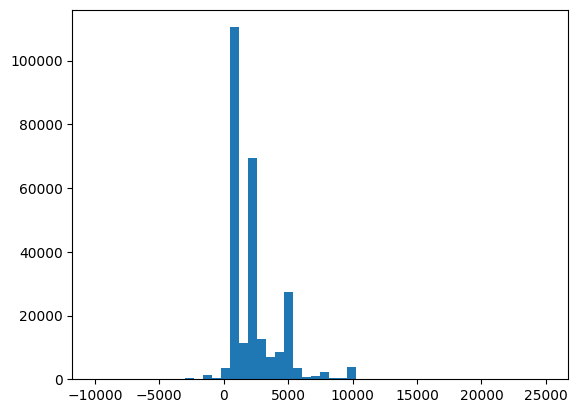

In [22]:
import matplotlib.pyplot as plt
plt.hist(prior["prior_amount"], bins = 50)

In [4]:
total = (
        contributions
        .group_by(["cmte_id", "rcpt_cmte", "cycle", "election_indicator"])
        .agg([
            pl.col("amount").sum().alias("contribute_amount"),
        ])
    )

In [10]:
total.filter(pl.col("cycle") == 2022).sort(["contribute_amount"], descending=True)

cmte_id,rcpt_cmte,cycle,election_indicator,contribute_amount
str,str,i64,str,f64
"""C00236760""","""C00498568""",2022,"""P2022""",15000.0
"""C00217877""","""C00620518""",2022,"""P""",15000.0
"""C00010470""","""C00718627""",2022,"""P2020""",15000.0
"""C00357863""","""C00466482""",2022,"""G2022""",10500.0
"""C00096156""","""C00665752""",2022,"""P2022""",10000.0
…,…,…,…,…
"""C00142711""","""C00547570""",2022,"""R2020""",-5000.0
"""C00117424""","""C00431353""",2022,"""P2024""",-7500.0
"""C00284810""","""C00193342""",2022,"""G2020""",-7500.0


In [9]:
contributions.filter(pl.col("amendment") != "N").head()

cmte_id,transaction_type,election_indicator,amendment,name,city,state,zip,amount,rcpt_cmte,memo,year,month,day,cmte_nm,connected_org_nm,corporation,parent,website,ttl_receipts,instrument,cusip,isin,common_name,business_description,ric,former_name,business_name,hq,hq_state,hq_city,permid,parent_hq,parent_permid,GICS_ID,GICS_Sector,GICS_Industry_Group,GICS_Industry,GIS_Subindustry,ICB_ID,ICB_Industry,ICB_Super_Sector,ICB_Sector,ICB_Sub_Sector,Incorporation_Date,Public_Date,IPO_Date,Retire_Date,Inactive_Year,Inactive_Event,Listing_Status,TRBC_ID,TRBC_Econ_Sector,TRBC_Business_Sector,TRBC_Industry_Group,TRBC_Industry,TRBC_Activity,NAICS_ID,NAICS_Sector,NAICS_Subsector,NAICS_Industry_Group,NAICS_International_Industry,NAICS_National_Industry,index,cycle,cand_id,cmte_type
str,str,str,str,str,str,str,str,f64,str,str,i64,i64,i64,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str,str,str,f64,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,i64,str,str
"""C00111559""","""24K""","""P""","""A""","""BARNEY FRANK FOR CONGRESS COMM…","""NEWTONVILLE""","""MA""","""02460""",2500.0,"""C00128868""",null,2004,1,23,"""credit suisse first boston gov…","""credit suisse first boston""","""CREDIT SUISSE FIRST BOSTON""",null,null,565031.43,"""5000047630""",null,null,"""Credit Suisse Securities (USA)…","""Credit Suisse Securities (USA)…",null,"""Credit Suisse First Boston LLC""",null,"""United States of America""","""NEW YORK""","""New York City""",5.0000e9,"""Switzerland""",5.0433e9,null,null,null,null,null,null,null,null,null,null,"""12/19/2002""",null,null,null,null,null,null,"""['5510201012', '5510203010', '…","""['Financials', 'Financials', '…","""['Banking & Investment Service…","""['Investment Banking & Investm…","""['Investment Banking & Brokera…","""['Brokerage Services', 'Divers…","""['523150', '523940']""","""['Finance and Insurance', 'Fin…","""['Securities, Commodity Contra…","""['Securities and Commodity Con…","""['Investment Banking and Secur…","""['Investment Banking and Secur…",null,2004,"""H0MA04036""","""P"""
"""C00111559""","""24K""","""G""","""A""","""BACHUS FOR CONGRESS COMMITTEE""","""BIRMINGHAM""","""AL""","""35259""",2000.0,"""C00260547""",null,2004,1,23,"""credit suisse first boston gov…","""credit suisse first boston""","""CREDIT SUISSE FIRST BOSTON""",null,null,565031.43,"""5000047630""",null,null,"""Credit Suisse Securities (USA)…","""Credit Suisse Securities (USA)…",null,"""Credit Suisse First Boston LLC""",null,"""United States of America""","""NEW YORK""","""New York City""",5.0000e9,"""Switzerland""",5.0433e9,null,null,null,null,null,null,null,null,null,null,"""12/19/2002""",null,null,null,null,null,null,"""['5510201012', '5510203010', '…","""['Financials', 'Financials', '…","""['Banking & Investment Service…","""['Investment Banking & Investm…","""['Investment Banking & Brokera…","""['Brokerage Services', 'Divers…","""['523150', '523940']""","""['Finance and Insurance', 'Fin…","""['Securities, Commodity Contra…","""['Securities and Commodity Con…","""['Investment Banking and Secur…","""['Investment Banking and Secur…",null,2004,"""H2AL06035""","""P"""
"""C00111559""","""24K""","""P""","""A""","""BAKER FOR CONGRESS COMMITTEE""","""BATON ROUGE""","""LA""","""70821""",1000.0,"""C00196501""",null,2004,1,23,"""credit suisse first boston gov…","""credit suisse first boston""","""CREDIT SUISSE FIRST BOSTON""",null,null,565031.43,"""5000047630""",null,null,"""Credit Suisse Securities (USA)…","""Credit Suisse Securities (USA)…",null,"""Credit Suisse First Boston LLC""",null,"""United States of America""","""NEW YORK""","""New York City""",5.0000e9,"""Switzerland""",5.0433e9,null,null,null,null,null,null,null,null,null,null,"""12/19/2002""",null,null,null,null,null,null,"""['5510201012', '5510203010', '…","""['Financials', 'Financials', '…","""['Banking & Investment Service…","""['Investment Banking & Investm…","""['Investment Banking & Brokera

In [357]:
corporate_pacs = pd.read_csv("../data/cpac/corporate_pacs_2004_2024.csv", dtype={"PermID":str})
public_firms = pd.read_csv("../data/firms/public_firms.csv", dtype={"PermID":str})
private_firms = pd.read_csv("../data/firms/private_firms.csv", dtype={"PermID":str})

In [358]:
list_col = ["TRBC_ID", "TRBC_Econ_Sector", "TRBC_Business_Sector", "TRBC_Industry_Group",
            "TRBC_Industry", "TRBC_Activity", "NAICS_ID", "NAICS_Sector", "NAICS_Subsector",
            "NAICS_Industry_Group", "NAICS_International_Industry", "NAICS_National_Industry"]
for col in list_col:
    public_firms[col] = public_firms[col].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else None)
    private_firms[col] = private_firms[col].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else None)

In [359]:
cpac_2024_public = corporate_pacs.loc[((corporate_pacs["YEAR"] == 2024) & (~corporate_pacs["RIC"].isna())), ].reset_index(drop=True)
cpac_2024_private = corporate_pacs.loc[((corporate_pacs["YEAR"] == 2024) & (corporate_pacs["RIC"].isna())), ].reset_index(drop=True)

In [360]:
cpac_2024_public = pd.merge(cpac_2024_public[["CMTE_ID", "RIC", "PermID", "Parent", "Website"]],
                            public_firms,
                            how = "left",
                            left_on = "RIC", right_on = "Instrument",
                            suffixes = ("", "_public"))

In [361]:
cpac_2024_private = pd.merge(cpac_2024_private[["CMTE_ID", "RIC", "PermID", "Parent", "Website"]],
                             private_firms,
                             how = "left",
                             left_on = "PermID", right_on = "Instrument",
                             suffixes = ("", "_private"))

In [362]:
cpac_2024 = pd.concat([cpac_2024_public, cpac_2024_private]).reset_index(drop=True)

In [363]:
cand_2024 = pd.read_parquet("../data/candidates/candidate_master_2024.parquet")
contrib_2024 = pd.read_csv("../data/contributions/committees/corp_candidate_2024.csv")

C:\Users\zih028\AppData\Local\Temp\ipykernel_23244\2764639069.py:2: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  contrib_2024 = pd.read_csv("../data/contributions/committees/corp_candidate_2024.csv")


In [364]:
contrib_2024 = contrib_2024.loc[(contrib_2024["YEAR"] == 2024) & (contrib_2024["TRANSACTION_TP"] == "24K"), ["CMTE_ID", "TRANSACTION_AMT", "CAND_ID", "YEAR", "MONTH", "DAY"]].reset_index(drop=True)
cand_2024 = cand_2024.loc[cand_2024["CAND_ELECTION_YR"] >= 2024, ["CAND_ID", "CAND_NAME", "CAND_PTY_AFFILIATION", "CAND_OFFICE_ST", "CAND_OFFICE", "CAND_OFFICE_DISTRICT", "CAND_ICI"]].reset_index(drop=True)

In [365]:
contrib_2024 = pd.merge(contrib_2024, cand_2024,
                        how = "left", on = "CAND_ID")

In [366]:
agg_dict = {col: 'sum' if col == 'TRANSACTION_AMT' else 'first' for col in contrib_2024.columns if col not in ['CMTE_ID', 'CAND_ID']}
contrib_2024 = contrib_2024.groupby(["CMTE_ID", "CAND_ID"], as_index=False).agg(agg_dict)

In [367]:
contrib_2024 = contrib_2024.loc[contrib_2024["TRANSACTION_AMT"] > 0,]
contrib_2024["CAND_PTY_AFFILIATION"] = contrib_2024["CAND_PTY_AFFILIATION"].replace("DFL", "DEM")

In [368]:
partisan_2024 = contrib_2024.groupby(["CMTE_ID", "CAND_PTY_AFFILIATION", "CAND_OFFICE"], as_index=False)["TRANSACTION_AMT"].agg(count = "count", total = "sum")
incumbent_2024 = contrib_2024.groupby(["CMTE_ID", "CAND_ICI", "CAND_OFFICE"], as_index=False)["TRANSACTION_AMT"].agg(count = "count", total = "sum")

In [369]:
partisan_2024 = partisan_2024[partisan_2024["CAND_PTY_AFFILIATION"].isin(["DEM", "REP"])]

In [370]:
hedge_2024_party = partisan_2024.groupby(["CMTE_ID", "CAND_PTY_AFFILIATION"])[["count", "total"]].sum().unstack(fill_value=0)
hedge_2024_chamber = partisan_2024.groupby(["CMTE_ID", "CAND_OFFICE", "CAND_PTY_AFFILIATION"])[["count", "total"]].sum().unstack(["CAND_OFFICE", "CAND_PTY_AFFILIATION"], fill_value=0)

In [371]:
hedge_2024_party.columns = [f'{val}_{col}' for col, val in hedge_2024_party.columns]
hedge_2024_party = hedge_2024_party.reset_index()
hedge_2024_chamber.columns = [f'{val1}_{val2}_{col}' for col, val1, val2 in hedge_2024_chamber.columns]
hedge_2024_chamber = hedge_2024_chamber.reset_index()

In [372]:
def calc_hedge(df, col1, col2):
    a = df[col1]
    b = df[col2]
    return 1 - abs((a-b)/(a+b))

def calc_balance(df, col1, col2):
    a = df[col1]
    b = df[col2]
    return (a-b)/(a+b)

In [373]:
hedge_2024_party["hedge_count"] = calc_hedge(hedge_2024_party, "DEM_count", "REP_count")
hedge_2024_party["hedge_amount"] = calc_hedge(hedge_2024_party, "DEM_total", "REP_total")
hedge_2024_chamber["house_hedge_count"] = calc_hedge(hedge_2024_chamber, "H_DEM_count", "H_REP_count")
hedge_2024_chamber["house_hedge_amount"] = calc_hedge(hedge_2024_chamber, "H_DEM_total", "H_REP_total")
hedge_2024_chamber["senate_hedge_count"] = calc_hedge(hedge_2024_chamber, "S_DEM_count", "S_REP_count")
hedge_2024_chamber["senate_hedge_amount"] = calc_hedge(hedge_2024_chamber, "S_DEM_total", "S_REP_total")

hedge_2024_party["balance_count"] = calc_balance(hedge_2024_party, "DEM_count", "REP_count")
hedge_2024_party["balance_amount"] = calc_balance(hedge_2024_party, "DEM_total", "REP_total")
hedge_2024_chamber["house_balance_count"] = calc_balance(hedge_2024_chamber, "H_DEM_count", "H_REP_count")
hedge_2024_chamber["house_balance_amount"] = calc_balance(hedge_2024_chamber, "H_DEM_total", "H_REP_total")
hedge_2024_chamber["senate_balance_count"] = calc_balance(hedge_2024_chamber, "S_DEM_count", "S_REP_count")
hedge_2024_chamber["senate_balance_amount"] = calc_balance(hedge_2024_chamber, "S_DEM_total", "S_REP_total")

In [374]:
hedge_2024 = pd.merge(hedge_2024_party, hedge_2024_chamber,
                      how = "left", on = "CMTE_ID")

In [375]:
hedge_2024 = hedge_2024[["CMTE_ID", "hedge_count", "hedge_amount",
                         "house_hedge_count", "house_hedge_amount",
                         "senate_hedge_count", "senate_hedge_amount",
                         "balance_count", "balance_amount",
                         "house_balance_count", "house_balance_amount",
                         "senate_balance_count", "senate_balance_amount"]]

In [376]:
cpac_hedge_2024 = pd.merge(cpac_2024, hedge_2024,
                           how = "left", on = "CMTE_ID")

In [377]:
cpac_hedge_2024.to_csv("../data/hedging/cpac_hedging_2024.csv", index=False)

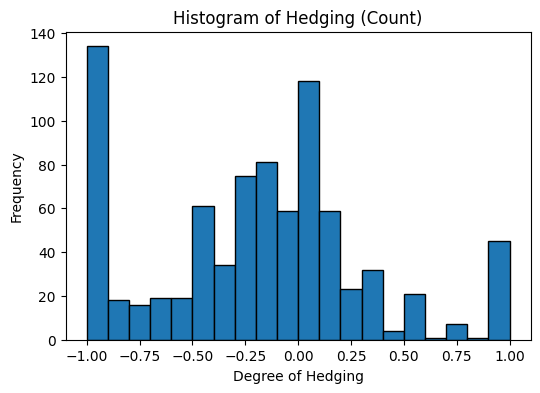

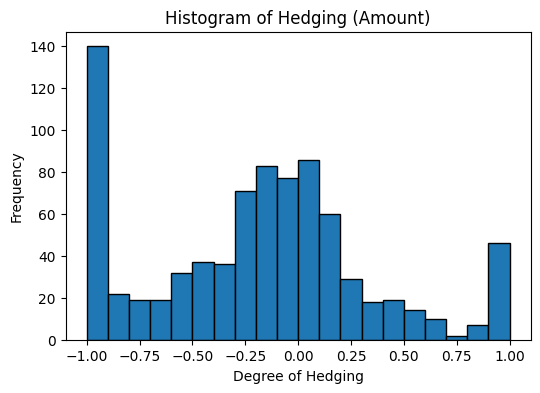

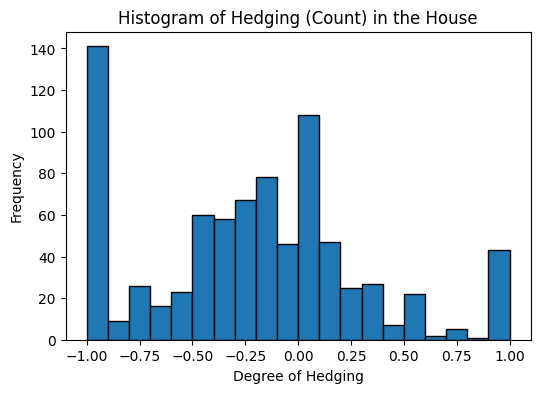

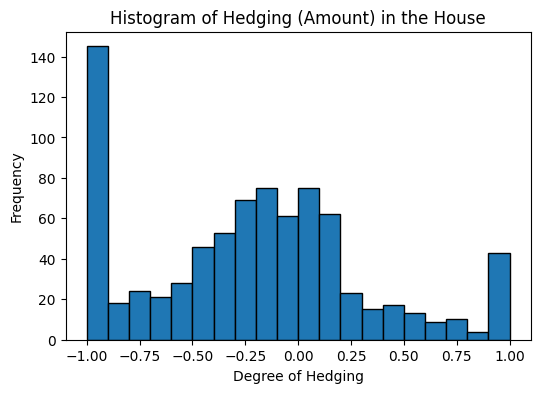

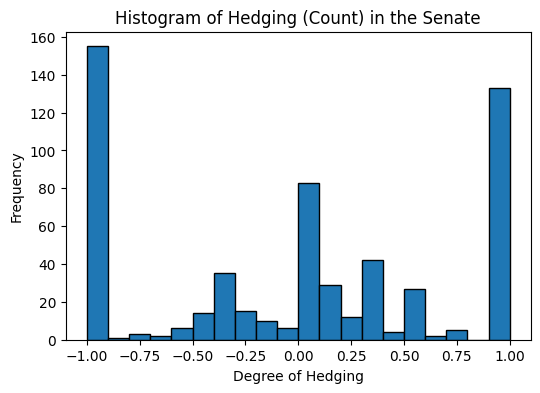

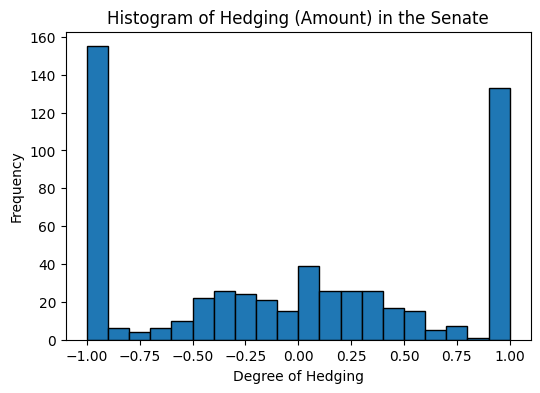

In [244]:
plt.figure(figsize=(6, 4))
plt.hist(cpac_hedge_2024['balance_count'].dropna(), bins=20, edgecolor='black')
plt.title('Histogram of Hedging (Count)')
plt.xlabel('Degree of Hedging')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(cpac_hedge_2024['balance_amount'].dropna(), bins=20, edgecolor='black')
plt.title('Histogram of Hedging (Amount)')
plt.xlabel('Degree of Hedging')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(cpac_hedge_2024['house_balance_count'].dropna(), bins=20, edgecolor='black')
plt.title('Histogram of Hedging (Count) in the House')
plt.xlabel('Degree of Hedging')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(cpac_hedge_2024['house_balance_amount'].dropna(), bins=20, edgecolor='black')
plt.title('Histogram of Hedging (Amount) in the House')
plt.xlabel('Degree of Hedging')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(cpac_hedge_2024['senate_balance_count'].dropna(), bins=20, edgecolor='black')
plt.title('Histogram of Hedging (Count) in the Senate')
plt.xlabel('Degree of Hedging')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(cpac_hedge_2024['senate_balance_amount'].dropna(), bins=20, edgecolor='black')
plt.title('Histogram of Hedging (Amount) in the Senate')
plt.xlabel('Degree of Hedging')
plt.ylabel('Frequency')
plt.show()

In [245]:
cpac_hedge_2024["Sector"] = cpac_hedge_2024["NAICS_Sector"].apply(lambda x: x[0] if isinstance(x, list) else x if not pd.isna(x) else None)

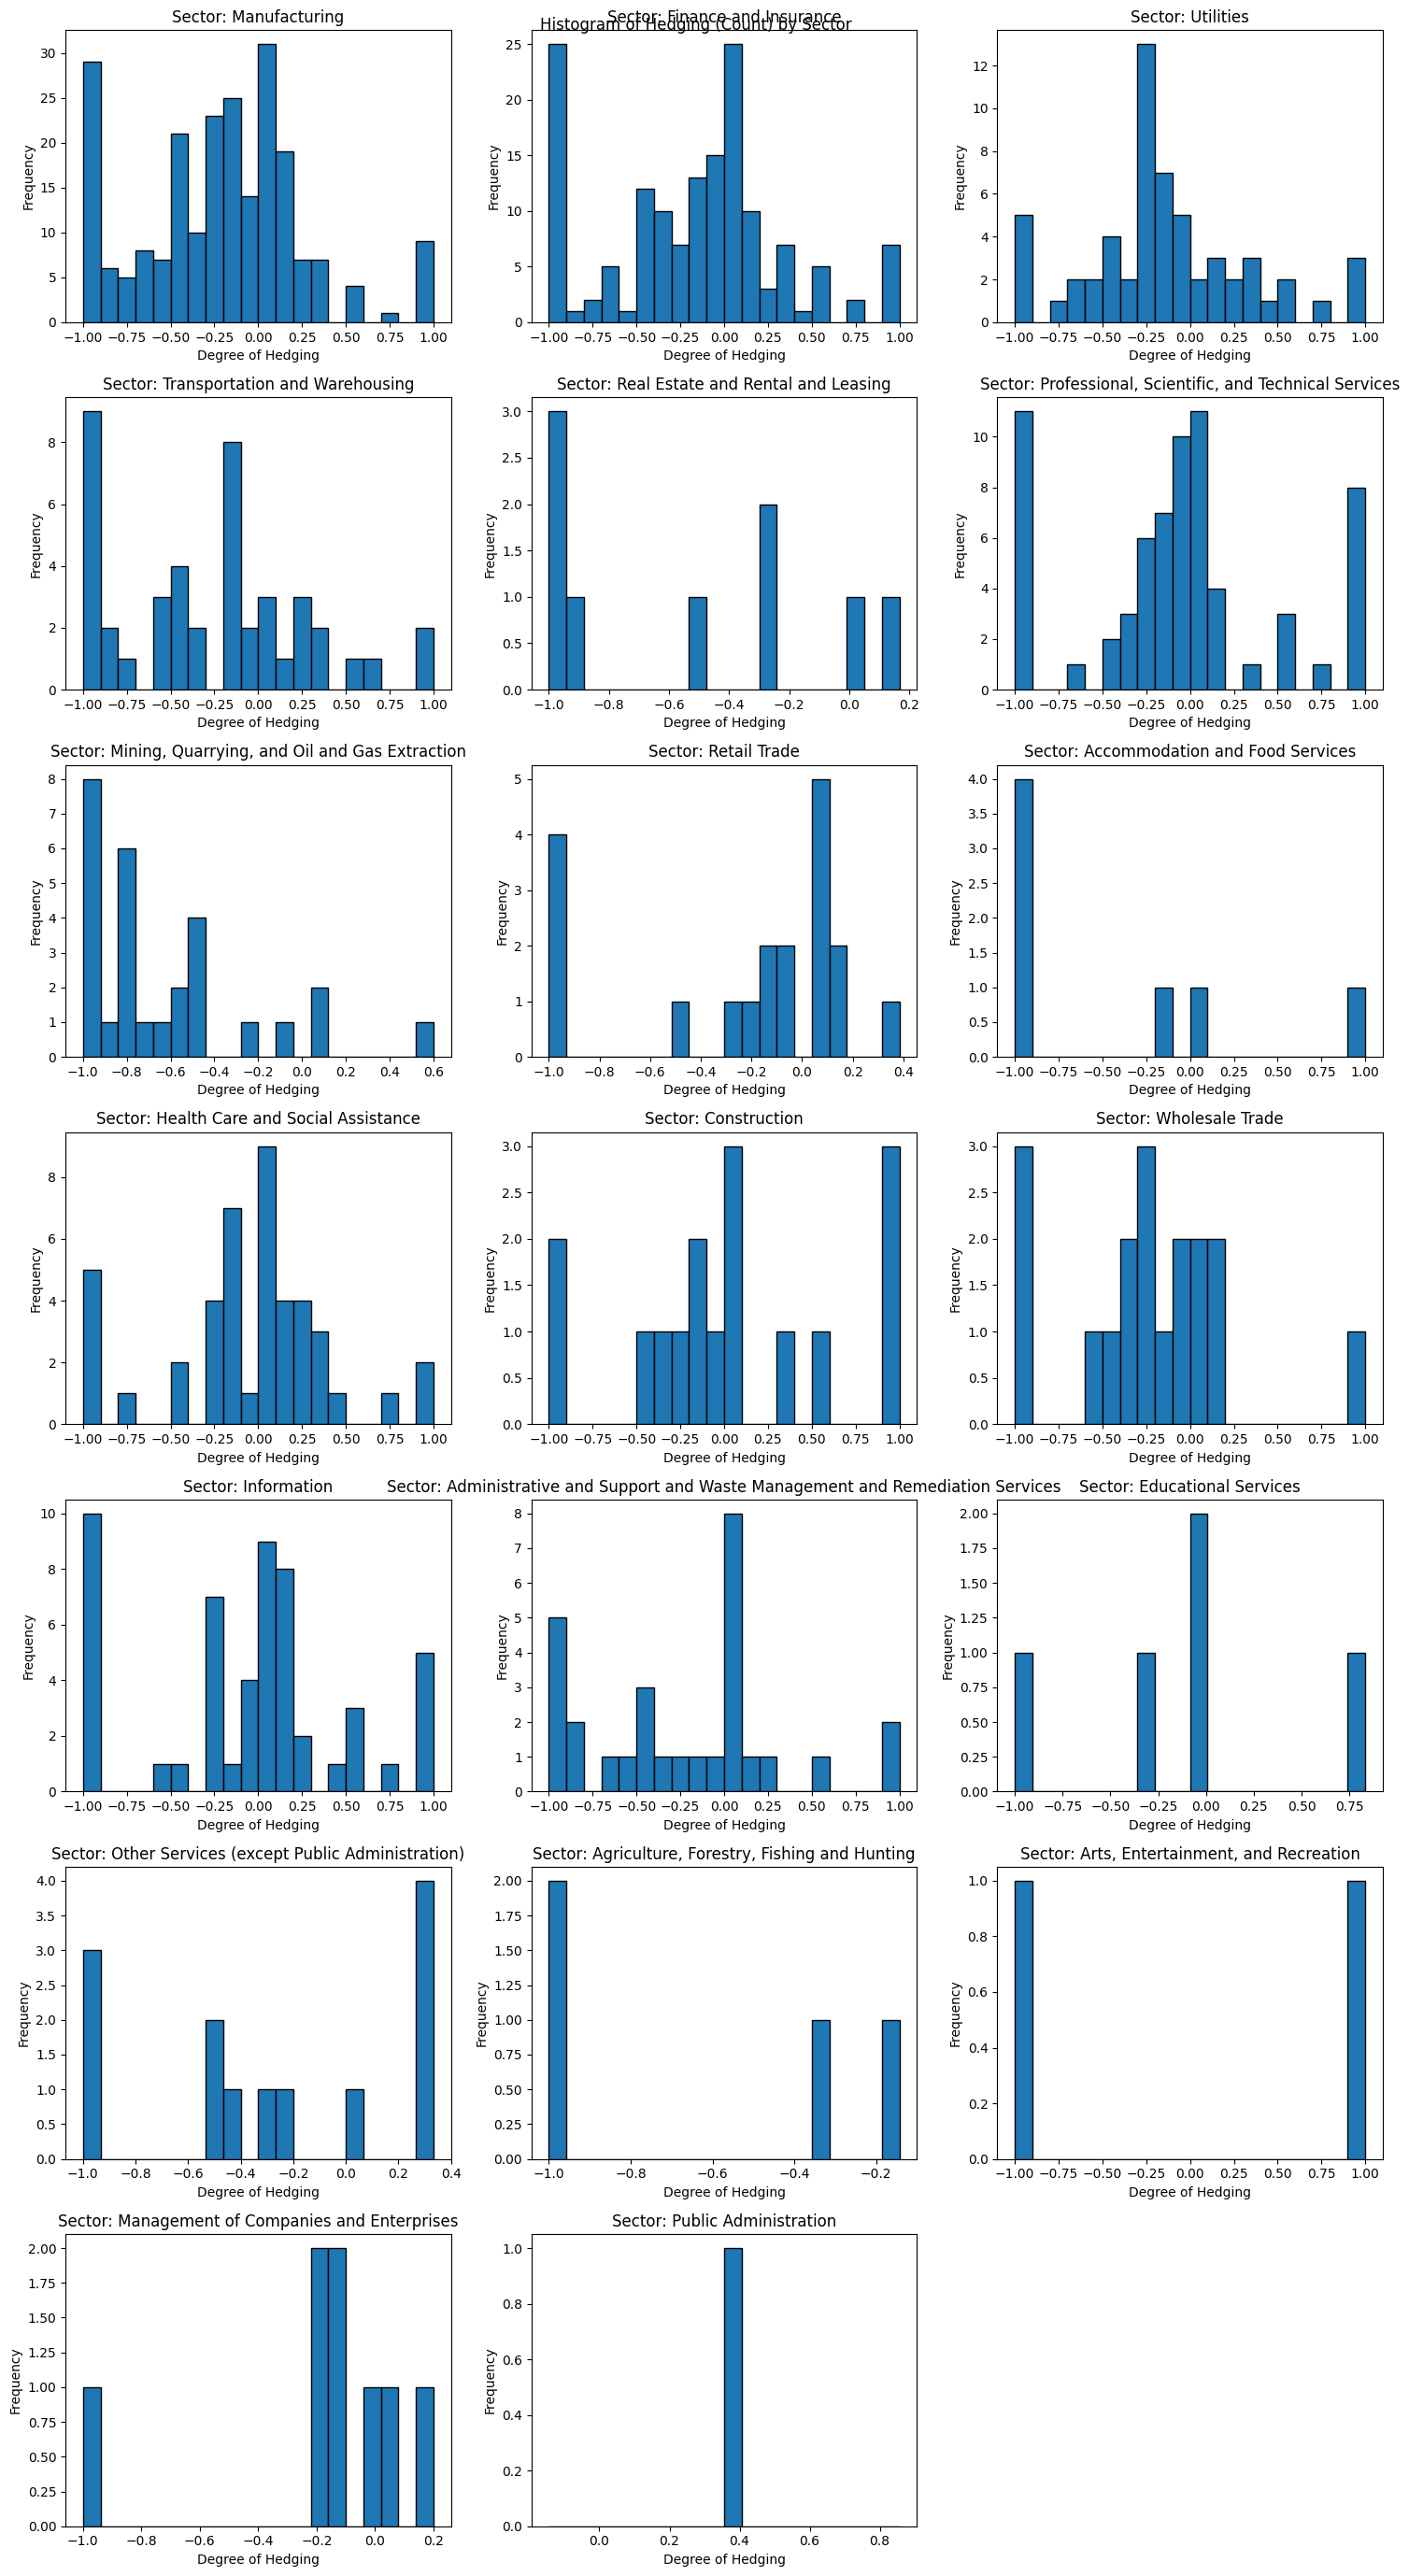

In [ ]:
groups = cpac_hedge_2024["Sector"].dropna().unique()
n_group = len(groups)
n_rows = math.ceil(n_group / 3)
fig, axs = plt.subplots(n_rows, 3, figsize = (15, n_rows * 4), squeeze=False)

for i, group in enumerate(groups):
    row = i // 3
    col = i % 3
    ax = axs[row][col]

    subset = cpac_hedge_2024[cpac_hedge_2024["Sector"] == group]
    ax.hist(subset['balance_count'].dropna(), bins=20, edgecolor='black')
    ax.set_title(f'Sector: {group}')
    ax.set_xlabel('Degree of Hedging')
    ax.set_ylabel('Frequency')

for j in range(i + 1, n_rows * 3):
    row = j // 3
    col = j % 3
    axs[row][col].set_visible(False)

plt.suptitle('Histogram of Hedging (Count) by Sector')
plt.tight_layout()
plt.show()

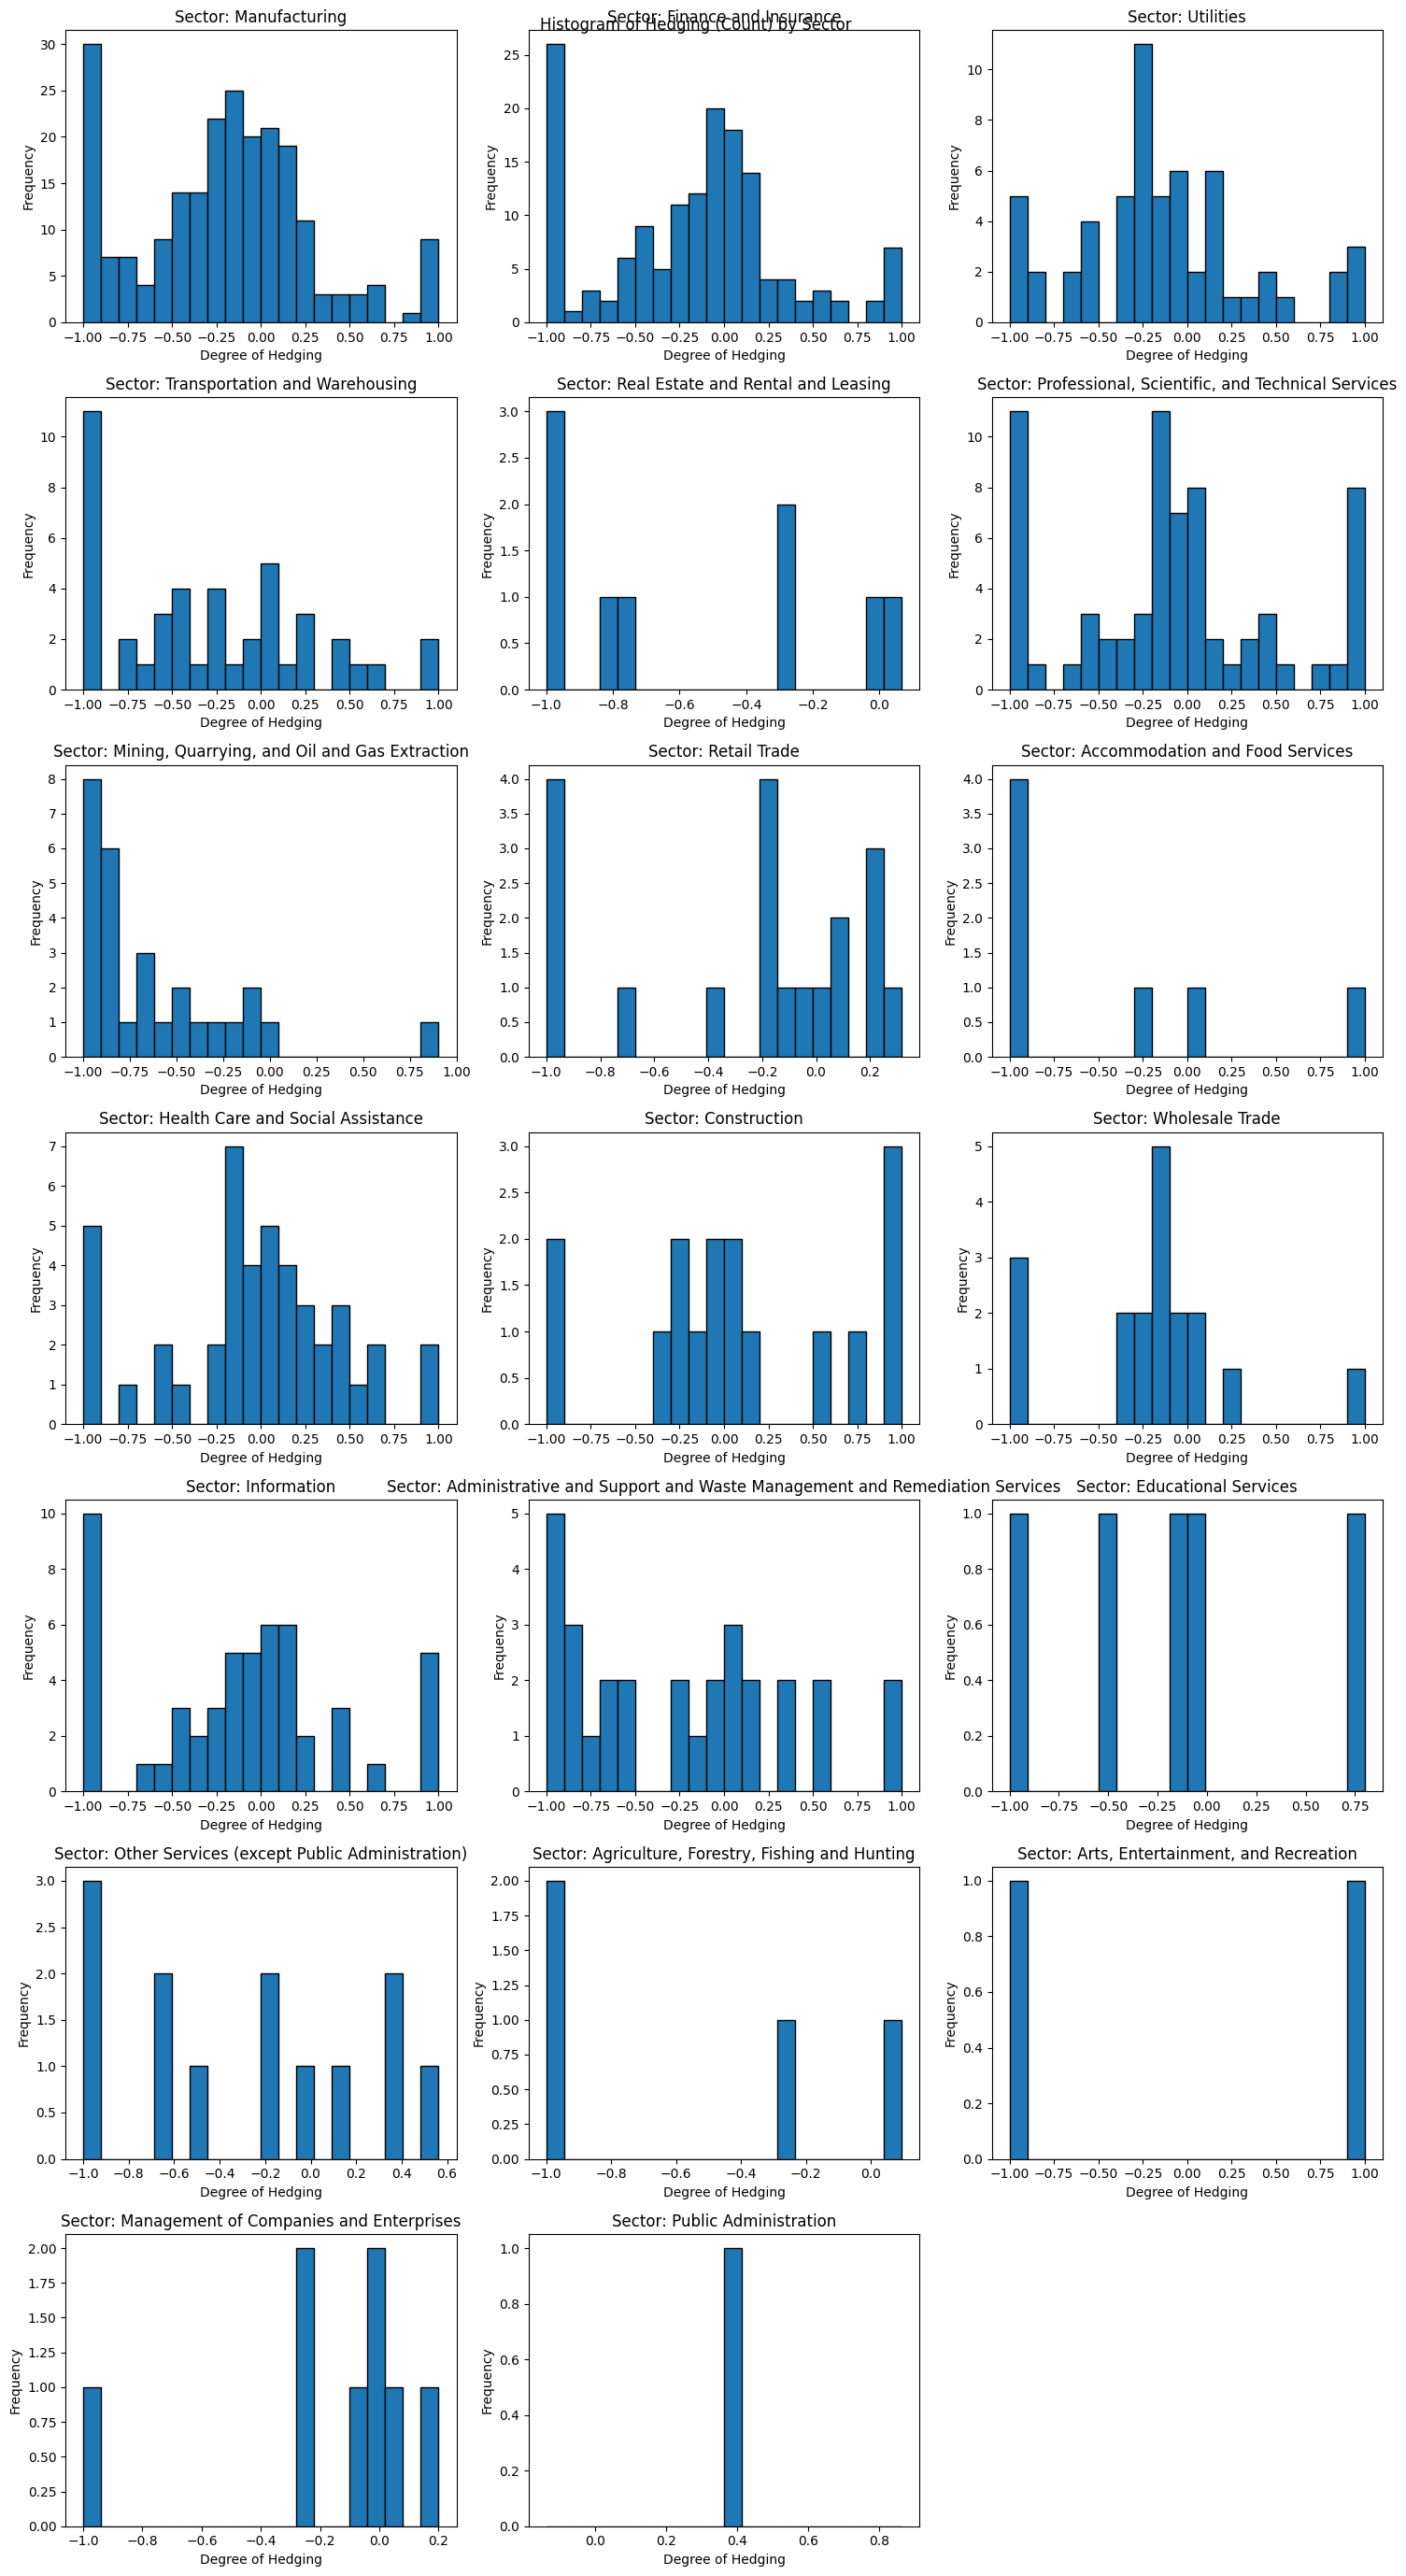

In [ ]:
groups = cpac_hedge_2024["Sector"].dropna().unique()
n_group = len(groups)
n_rows = math.ceil(n_group / 3)
fig, axs = plt.subplots(n_rows, 3, figsize = (15, n_rows * 4), squeeze=False)

for i, group in enumerate(groups):
    row = i // 3
    col = i % 3
    ax = axs[row][col]

    subset = cpac_hedge_2024[cpac_hedge_2024["Sector"] == group]
    ax.hist(subset['balance_amount'].dropna(), bins=20, edgecolor='black')
    ax.set_title(f'Sector: {group}')
    ax.set_xlabel('Degree of Hedging')
    ax.set_ylabel('Frequency')

for j in range(i + 1, n_rows * 3):
    row = j // 3
    col = j % 3
    axs[row][col].set_visible(False)

plt.suptitle('Histogram of Hedging (Amount) by Sector')
plt.tight_layout()
plt.show()

In [248]:
cpac_hedge_2024["Sector"] = cpac_hedge_2024["TRBC_Econ_Sector"].apply(lambda x: x[0] if isinstance(x, list) else x if not pd.isna(x) else None)

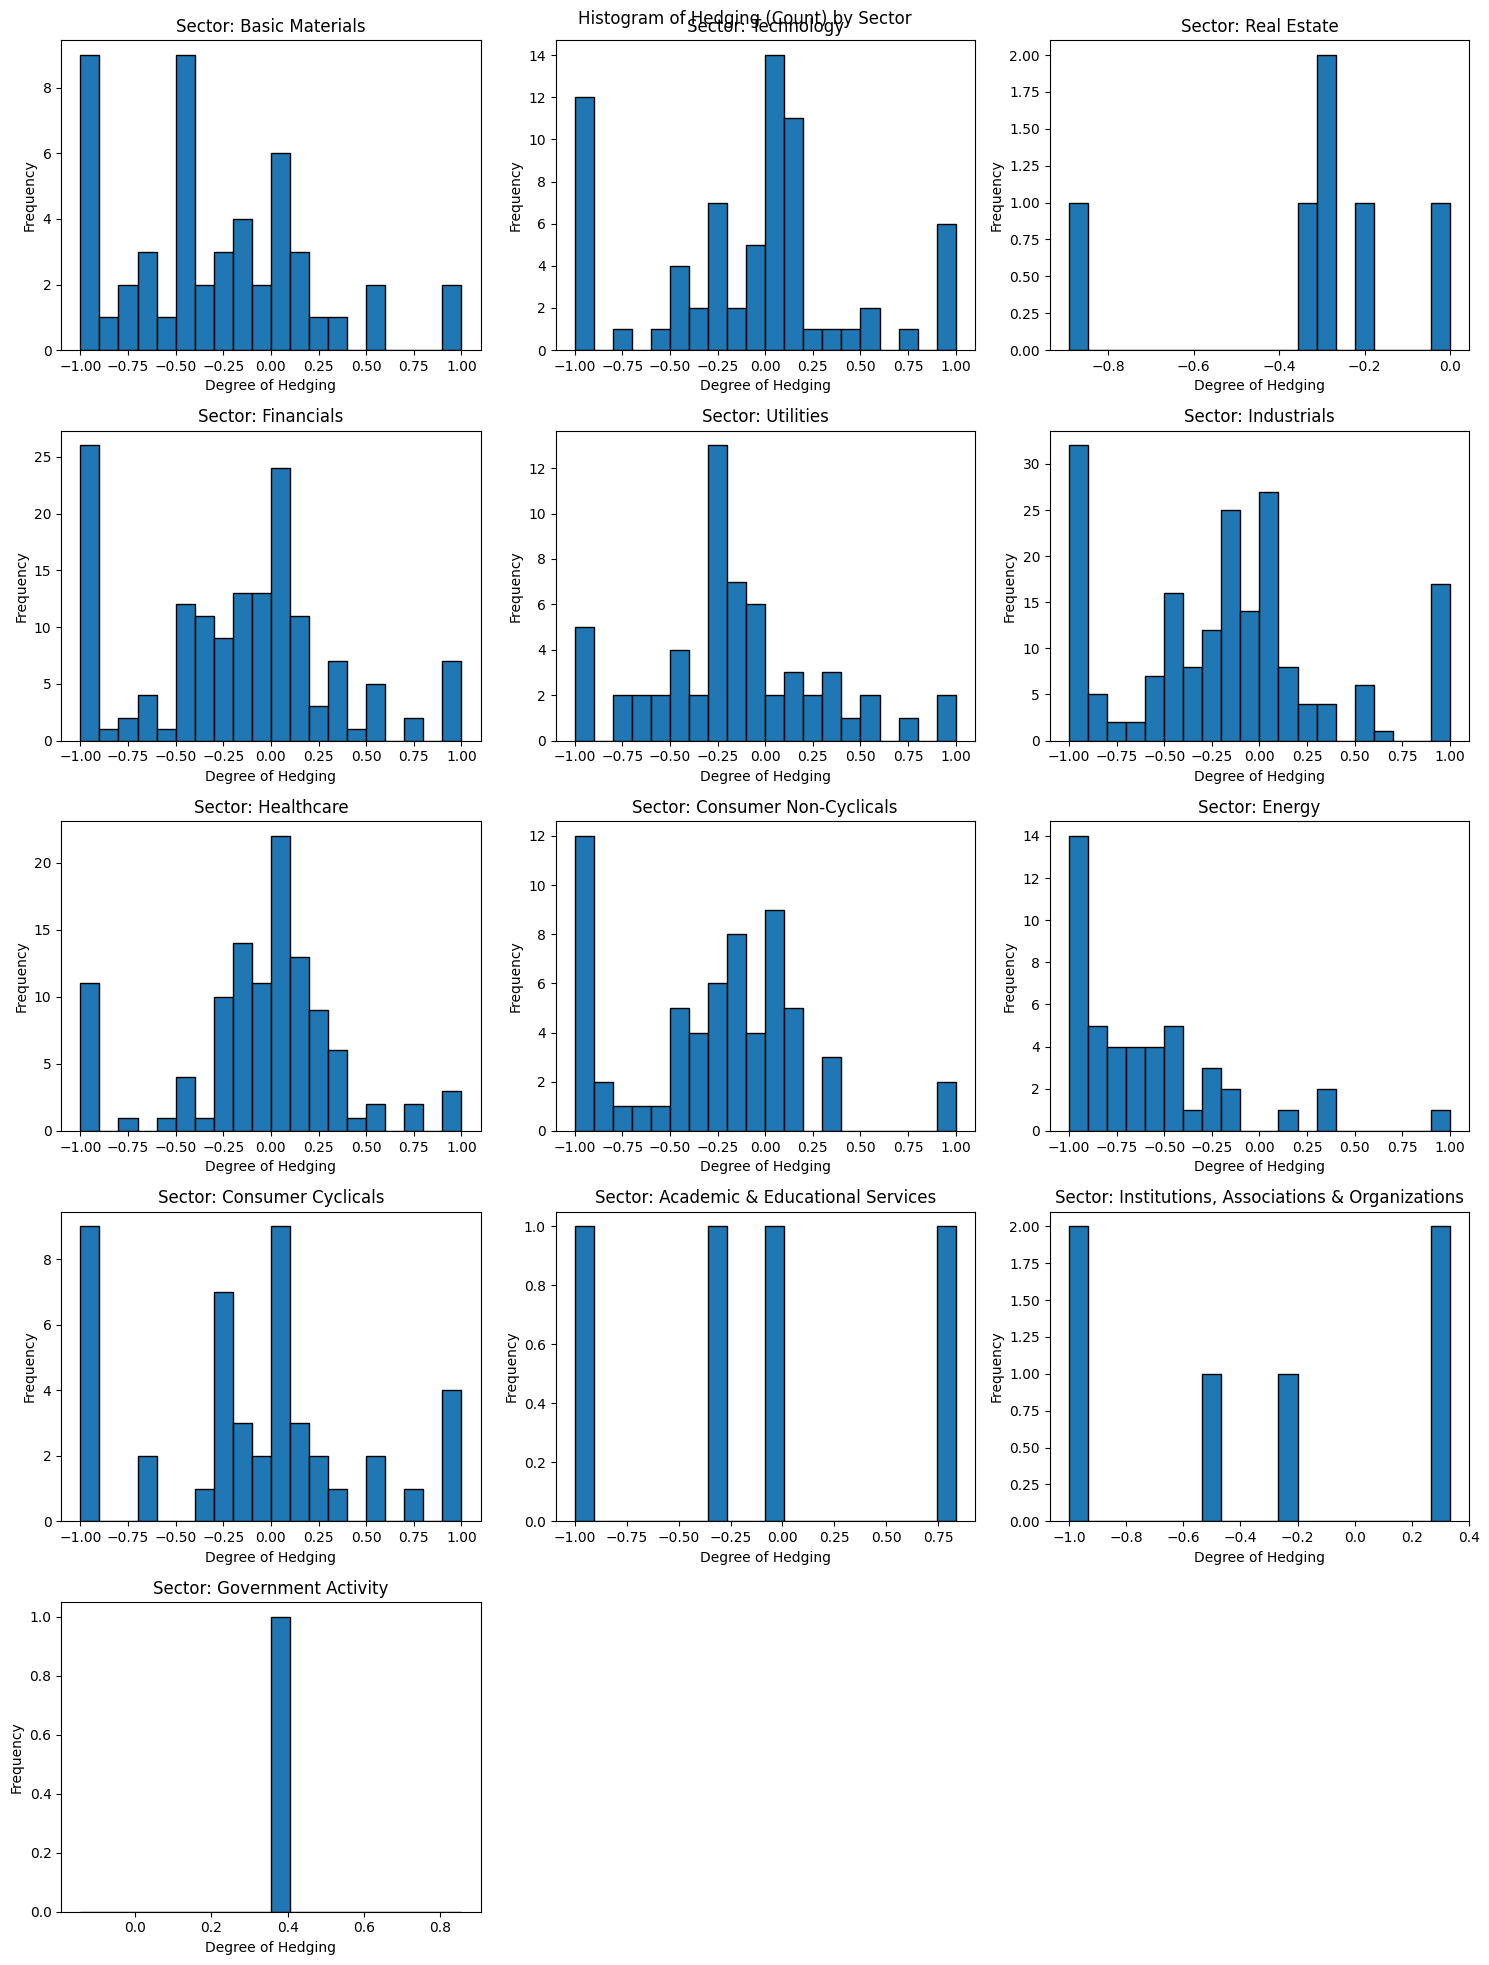

In [249]:
groups = cpac_hedge_2024["Sector"].dropna().unique()
n_group = len(groups)
n_rows = math.ceil(n_group / 3)
fig, axs = plt.subplots(n_rows, 3, figsize = (15, n_rows * 4), squeeze=False)

for i, group in enumerate(groups):
    row = i // 3
    col = i % 3
    ax = axs[row][col]

    subset = cpac_hedge_2024[cpac_hedge_2024["Sector"] == group]
    ax.hist(subset['balance_count'].dropna(), bins=20, edgecolor='black')
    ax.set_title(f'Sector: {group}')
    ax.set_xlabel('Degree of Hedging')
    ax.set_ylabel('Frequency')

for j in range(i + 1, n_rows * 3):
    row = j // 3
    col = j % 3
    axs[row][col].set_visible(False)

plt.suptitle('Histogram of Hedging (Count) by Sector')
plt.tight_layout()
plt.show()

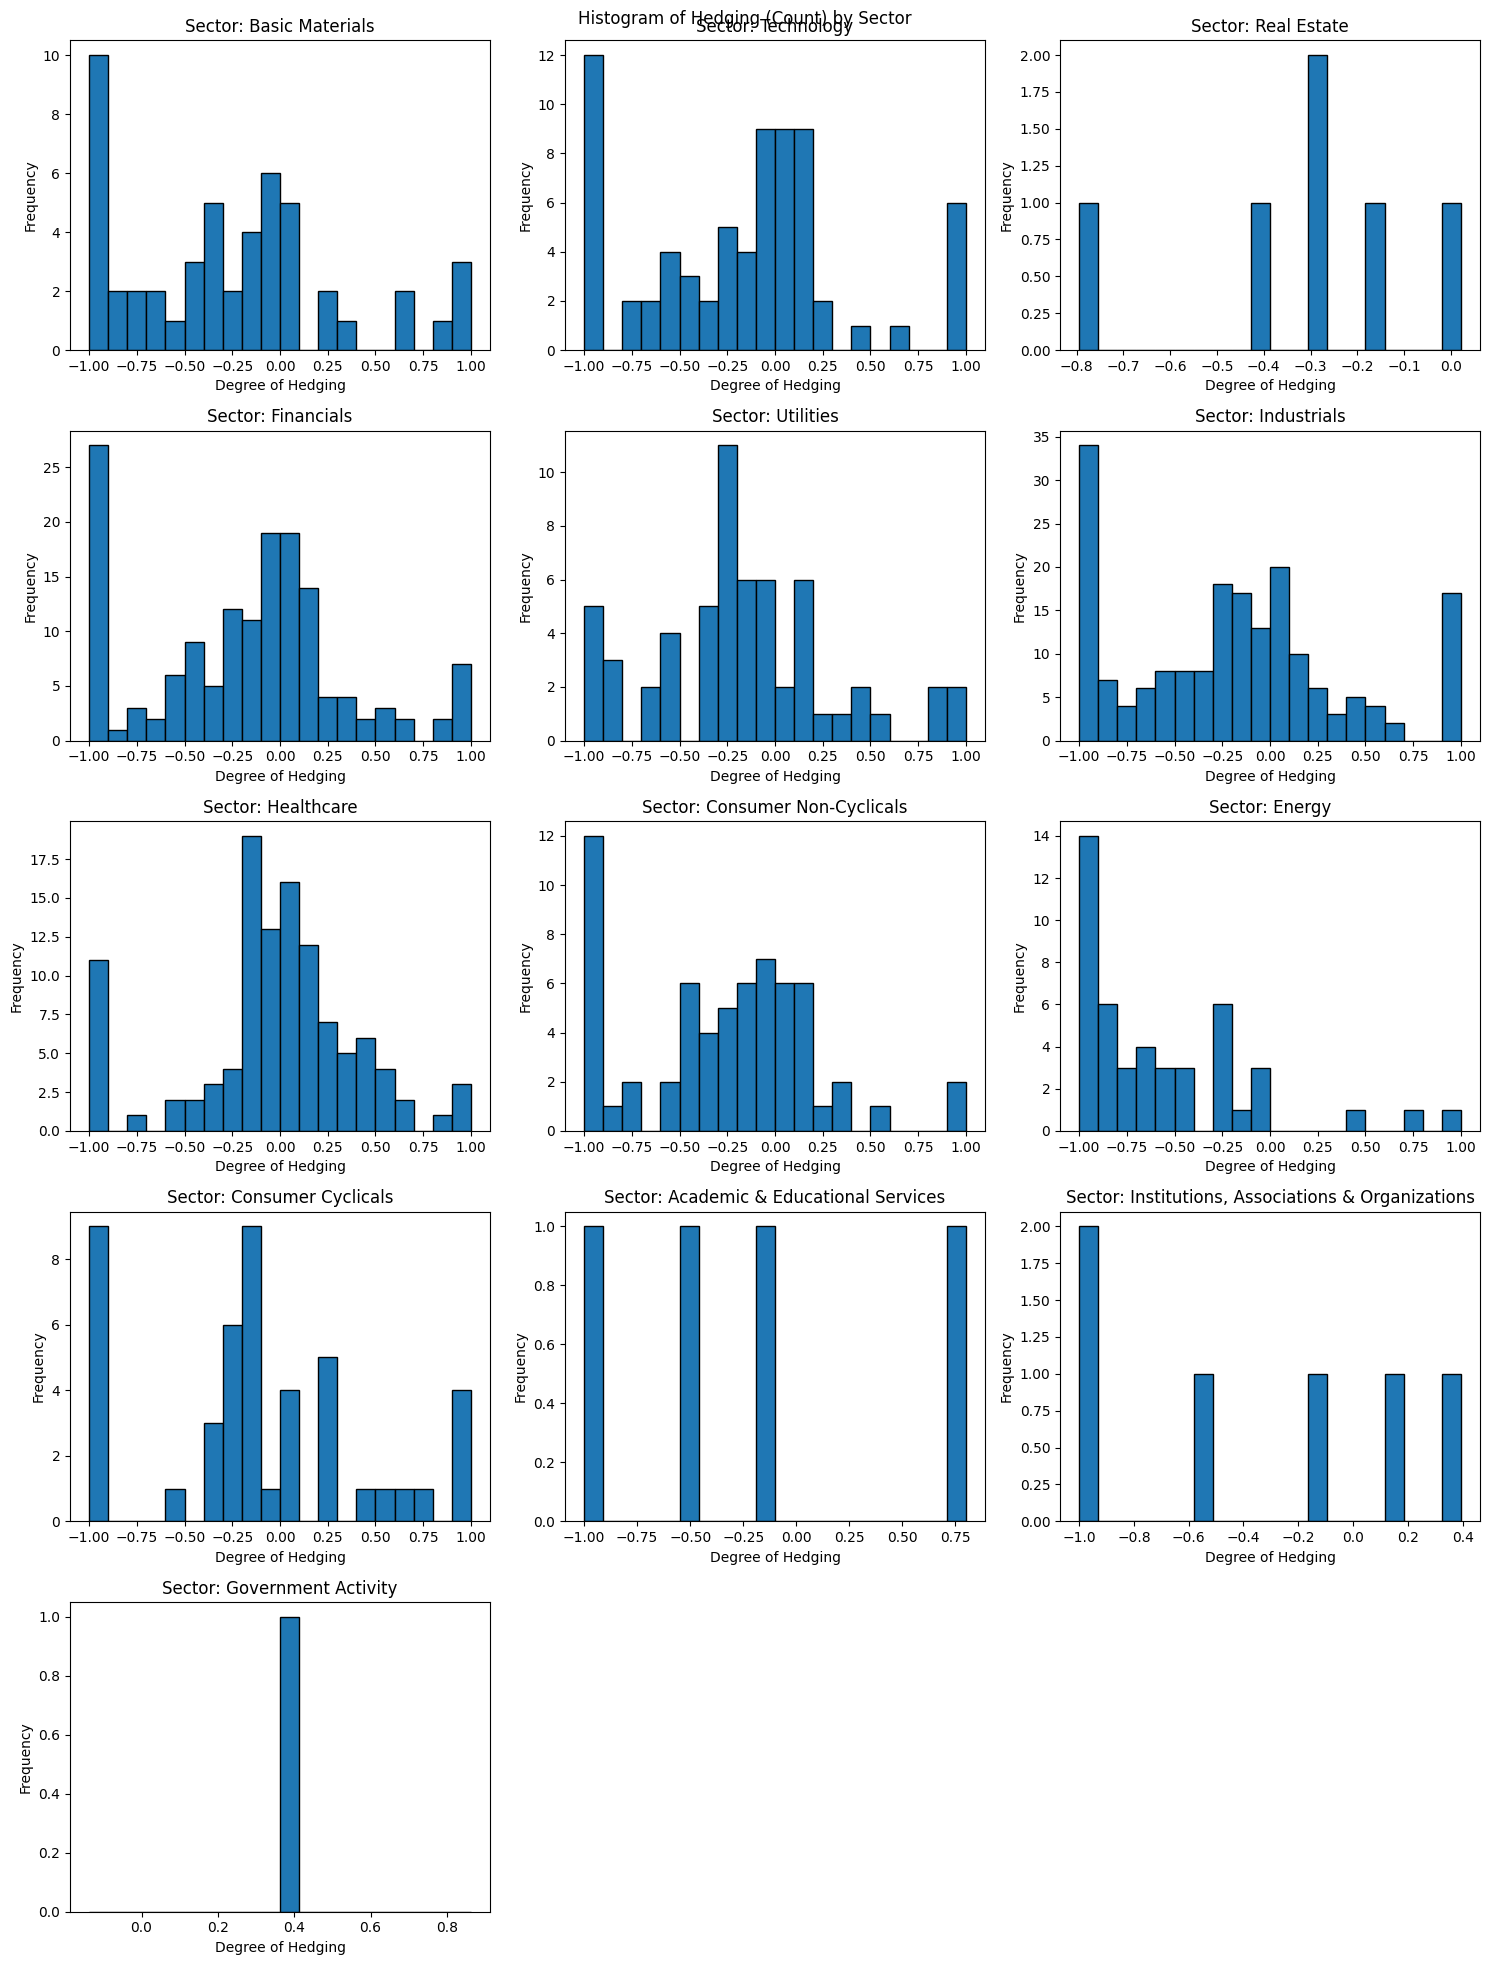

In [250]:
groups = cpac_hedge_2024["Sector"].dropna().unique()
n_group = len(groups)
n_rows = math.ceil(n_group / 3)
fig, axs = plt.subplots(n_rows, 3, figsize = (15, n_rows * 4), squeeze=False)

for i, group in enumerate(groups):
    row = i // 3
    col = i % 3
    ax = axs[row][col]

    subset = cpac_hedge_2024[cpac_hedge_2024["Sector"] == group]
    ax.hist(subset['balance_amount'].dropna(), bins=20, edgecolor='black')
    ax.set_title(f'Sector: {group}')
    ax.set_xlabel('Degree of Hedging')
    ax.set_ylabel('Frequency')

for j in range(i + 1, n_rows * 3):
    row = j // 3
    col = j % 3
    axs[row][col].set_visible(False)

plt.suptitle('Histogram of Hedging (Count) by Sector')
plt.tight_layout()
plt.show()

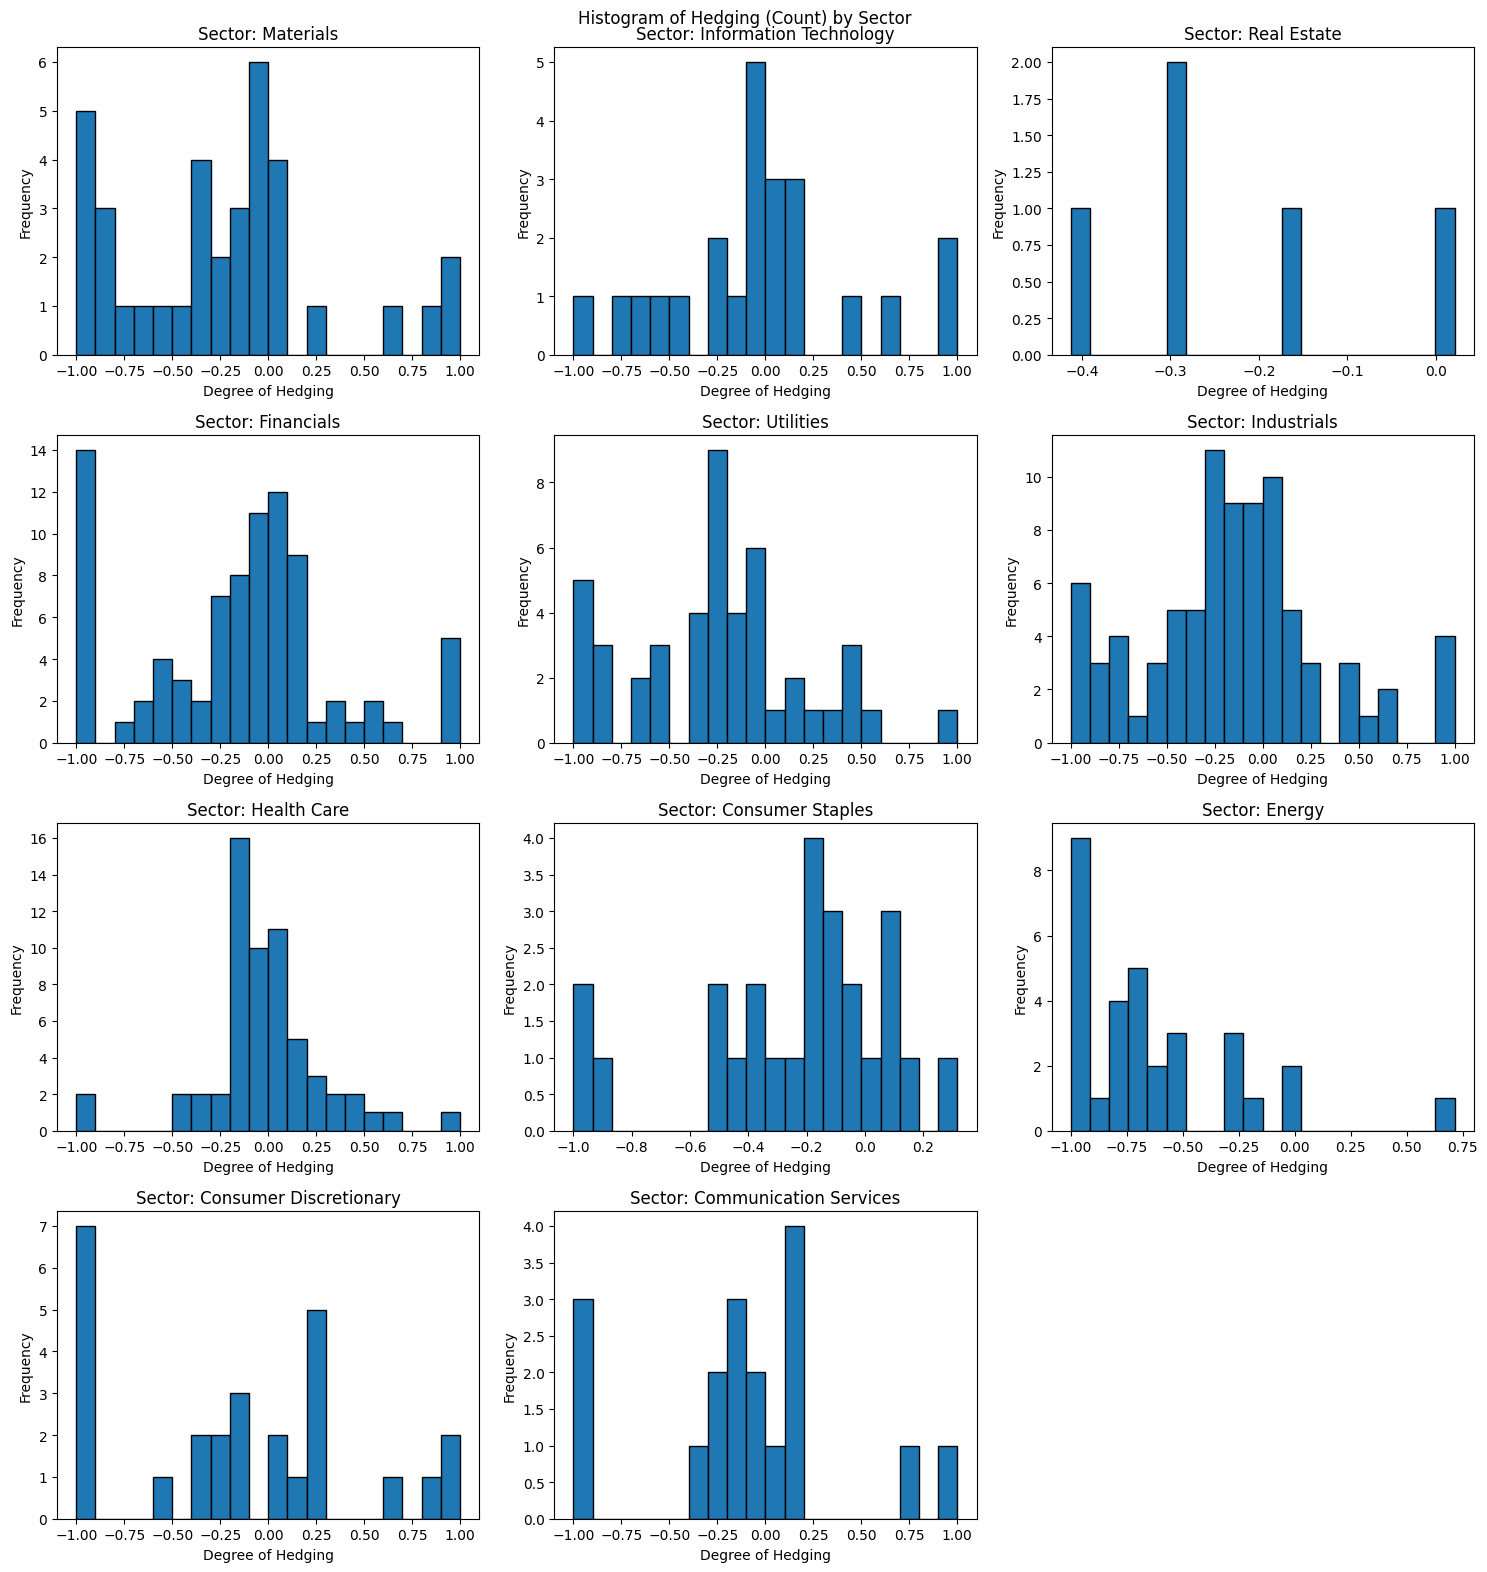

In [ ]:
groups = cpac_hedge_2024["GICS_Sector"].dropna().unique()
n_group = len(groups)
n_rows = math.ceil(n_group / 3)
fig, axs = plt.subplots(n_rows, 3, figsize = (15, n_rows * 4), squeeze=False)

for i, group in enumerate(groups):
    row = i // 3
    col = i % 3
    ax = axs[row][col]

    subset = cpac_hedge_2024[cpac_hedge_2024["GICS_Sector"] == group]
    ax.hist(subset['balance_amount'].dropna(), bins=20, edgecolor='black')
    ax.set_title(f'Sector: {group}')
    ax.set_xlabel('Degree of Hedging')
    ax.set_ylabel('Frequency')

for j in range(i + 1, n_rows * 3):
    row = j // 3
    col = j % 3
    axs[row][col].set_visible(False)

plt.suptitle('Histogram of Hedging (Amount) by Sector')
plt.tight_layout()
plt.show()

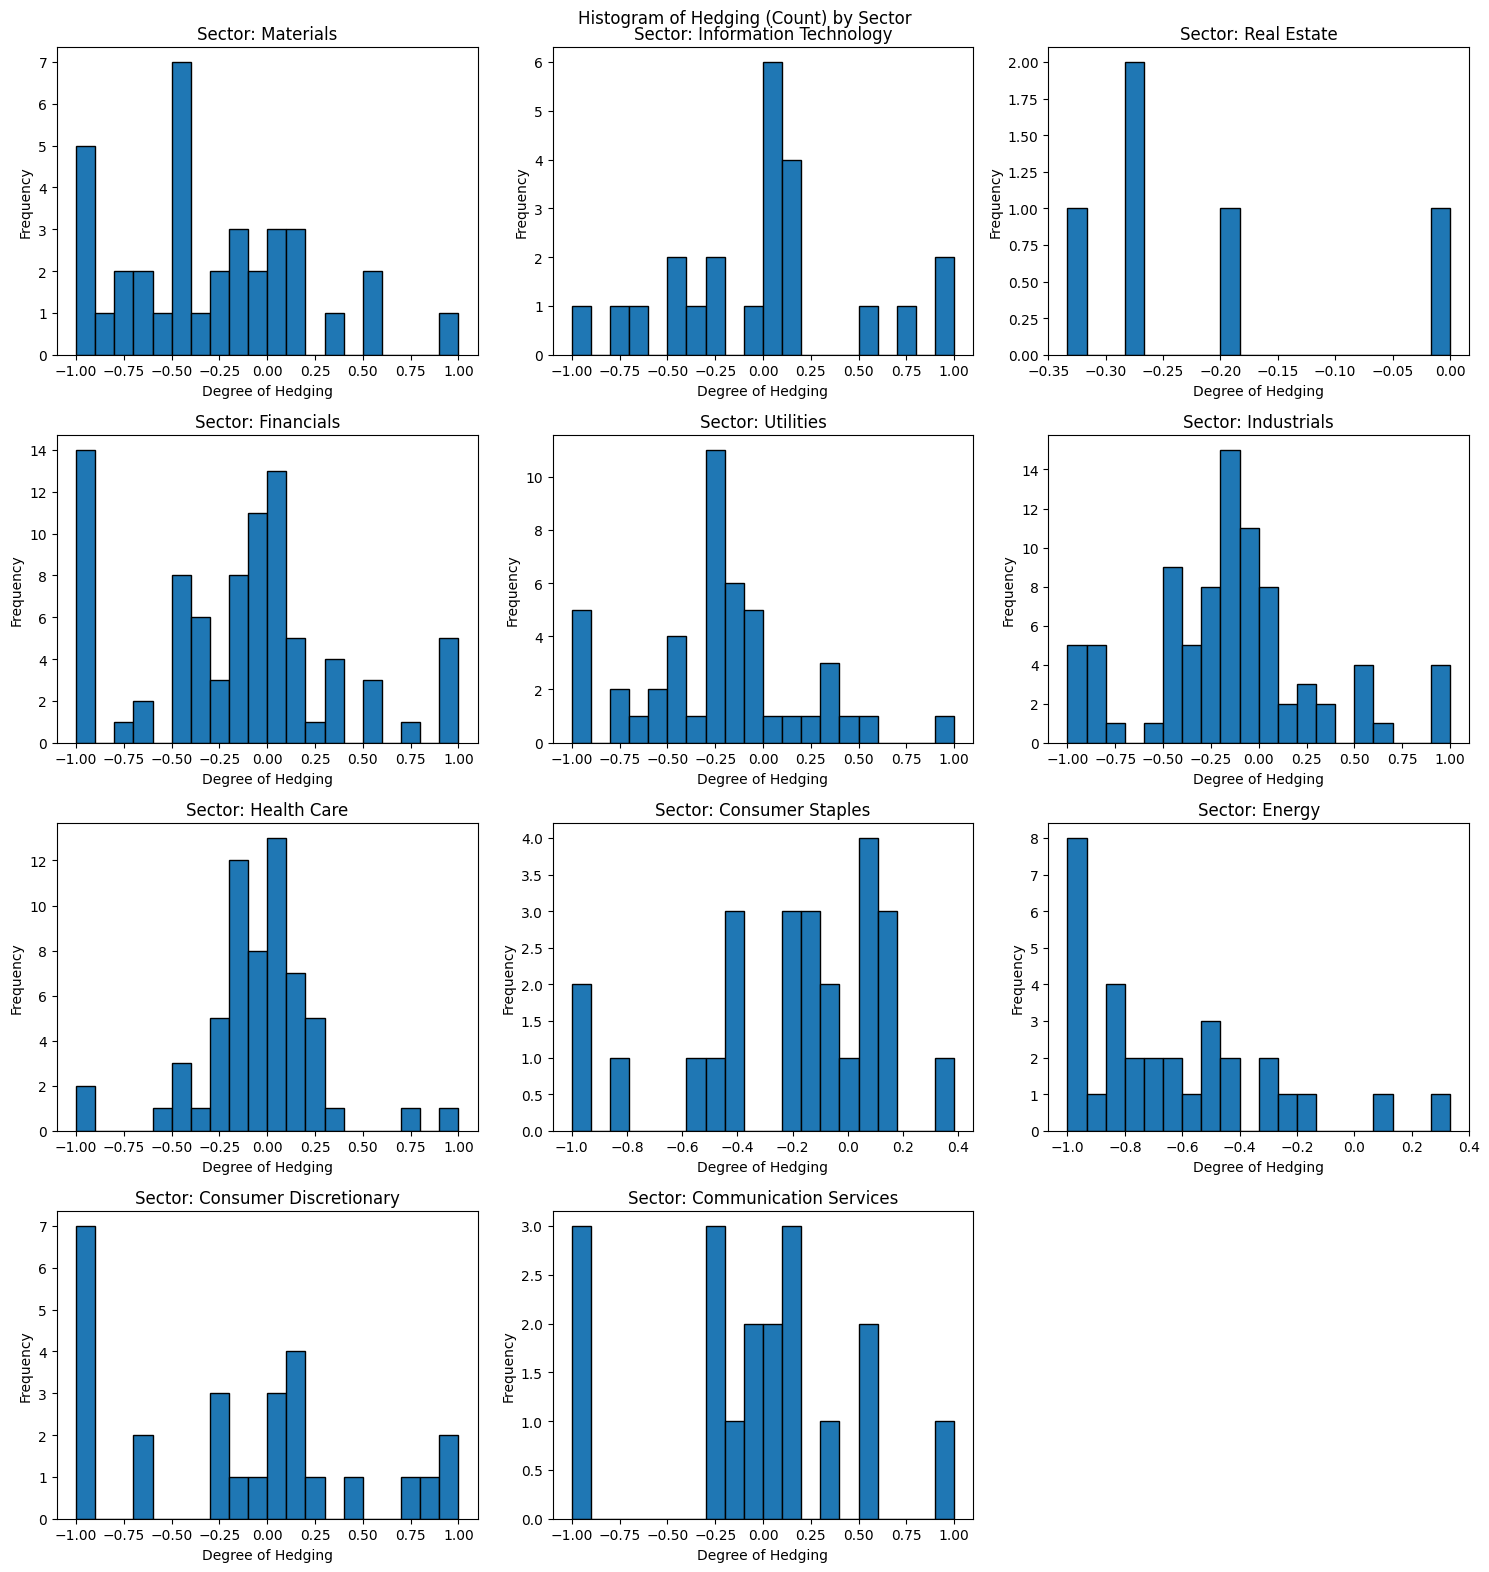

In [294]:
groups = cpac_hedge_2024["GICS_Sector"].dropna().unique()
n_group = len(groups)
n_rows = math.ceil(n_group / 3)
fig, axs = plt.subplots(n_rows, 3, figsize = (15, n_rows * 4), squeeze=False)

for i, group in enumerate(groups):
    row = i // 3
    col = i % 3
    ax = axs[row][col]

    subset = cpac_hedge_2024[cpac_hedge_2024["GICS_Sector"] == group]
    ax.hist(subset['balance_count'].dropna(), bins=20, edgecolor='black')
    ax.set_title(f'Sector: {group}')
    ax.set_xlabel('Degree of Hedging')
    ax.set_ylabel('Frequency')

for j in range(i + 1, n_rows * 3):
    row = j // 3
    col = j % 3
    axs[row][col].set_visible(False)

plt.suptitle('Histogram of Hedging (Count) by Sector')
plt.tight_layout()
plt.show()

In [289]:
cpac_hedge_2024.loc[~cpac_hedge_2024["RIC"].isna(),"GICS_Sector"]

0                   Materials
1      Information Technology
2                 Real Estate
3                  Financials
4                  Financials
                ...          
511               Health Care
512                 Materials
513                    Energy
514               Industrials
515                Financials
Name: GICS_Sector, Length: 516, dtype: object

In [378]:
contrib_sum_2024 = contrib_2024.groupby("CMTE_ID", as_index=False)["TRANSACTION_AMT"].agg("sum")

In [379]:
cpac_hedge_2024 = pd.merge(cpac_hedge_2024, contrib_sum_2024,
                           how = "left", on = "CMTE_ID")

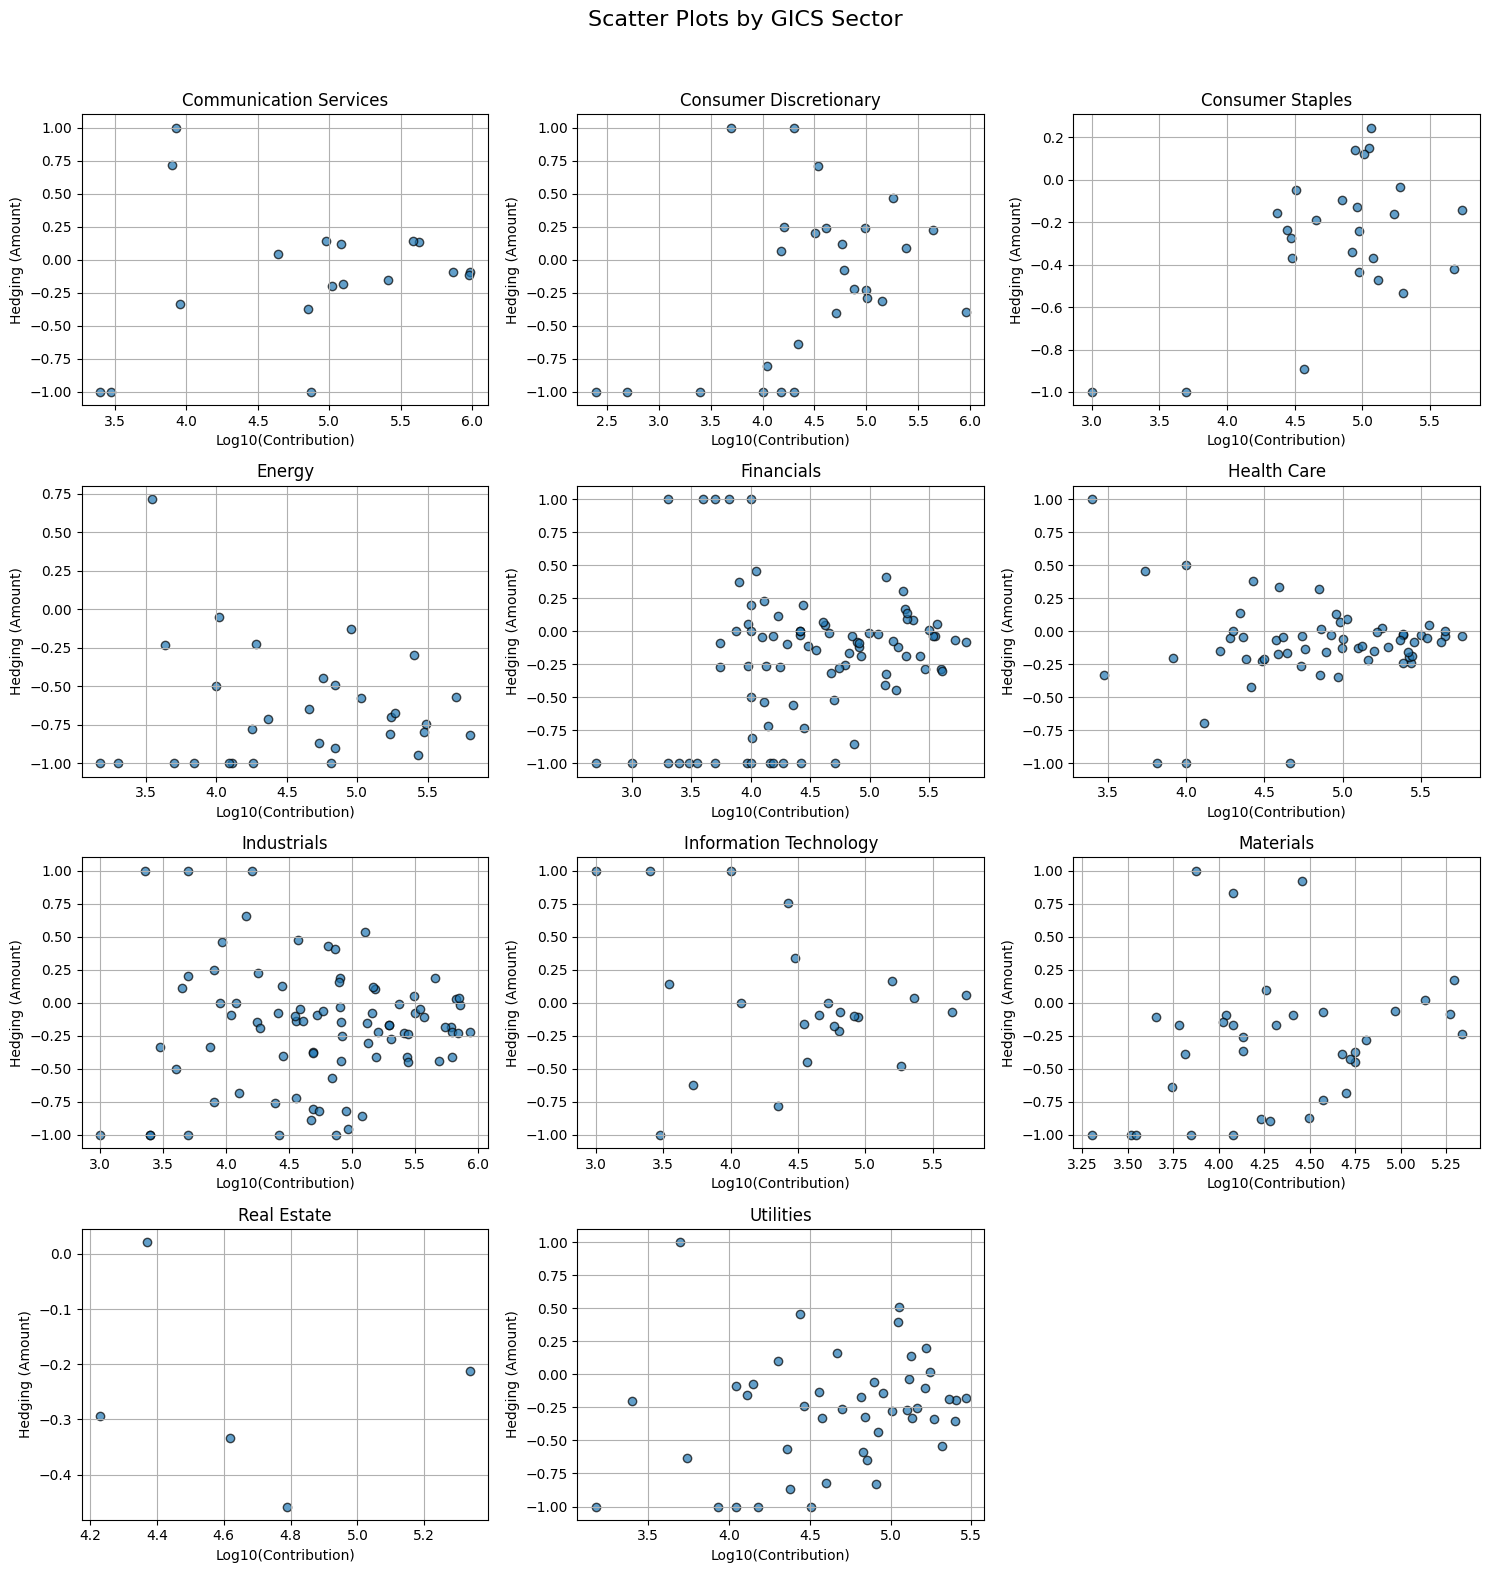

In [596]:
cpac_hedge_2024['log_amt'] = cpac_hedge_2024['TRANSACTION_AMT'].apply(lambda x: np.log10(x) if x > 0 else np.nan)
# Get unique sectors
sectors = cpac_hedge_2024['GICS_Sector'].dropna().unique()
sectors.sort()

# Plot layout
plots_per_row = 3
n_plots = len(sectors)
n_rows = math.ceil(n_plots / plots_per_row)

fig, axs = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row * 5, n_rows * 4), squeeze=False)

for i, sector in enumerate(sectors):
    row = i // plots_per_row
    col = i % plots_per_row
    ax = axs[row][col]
    
    subset = cpac_hedge_2024[cpac_hedge_2024['GICS_Sector'] == sector]
    ax.scatter(
        subset['log_amt'],
        subset['balance_amount'],
        alpha=0.7,
        edgecolor='k'
    )
    ax.set_title(sector)
    ax.set_xlabel('Log10(Contribution)')
    ax.set_ylabel('Hedging (Amount)')
    ax.grid(True)

# Hide any unused subplots
for j in range(n_plots, n_rows * plots_per_row):
    row, col = divmod(j, plots_per_row)
    axs[row][col].set_visible(False)

plt.suptitle('Scatter Plots by GICS Sector', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # reserve space for title
plt.show()

In [380]:
def count_unique(x):
    return len(set(x))

diverse_2024 = contrib_2024.dropna(subset="CAND_OFFICE_ST").groupby("CMTE_ID", as_index=False)[["CAND_OFFICE_ST", "CAND_NAME"]].agg(count_unique)
diverse_2024.columns = ["CMTE_ID", "n_states", "n_cands"]

In [381]:
cpac_hedge_2024 = pd.merge(cpac_hedge_2024, diverse_2024,
                           how = "left", on = "CMTE_ID")

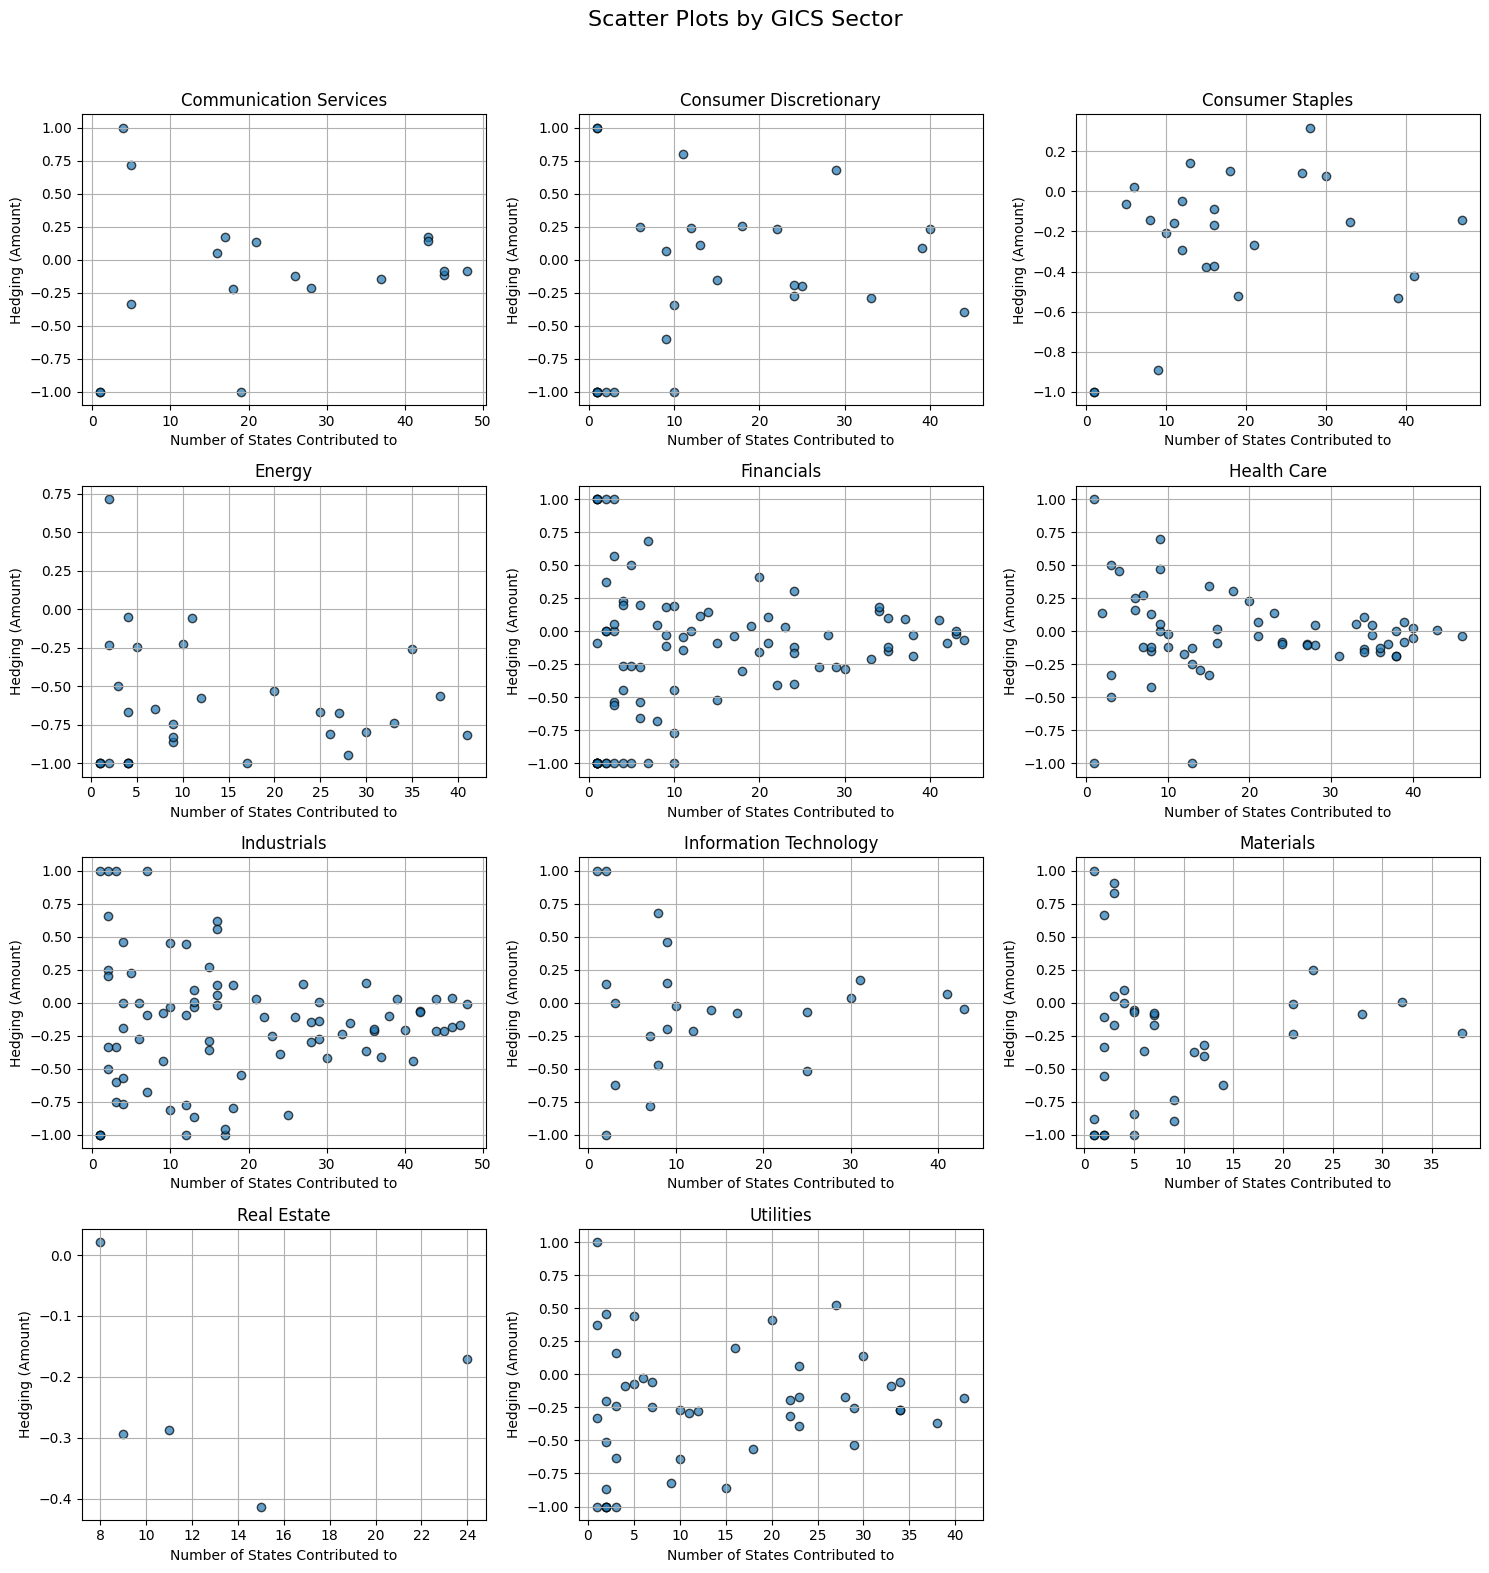

In [349]:
sectors = cpac_hedge_2024['GICS_Sector'].dropna().unique()
sectors.sort()

# Plot layout
plots_per_row = 3
n_plots = len(sectors)
n_rows = math.ceil(n_plots / plots_per_row)

fig, axs = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row * 5, n_rows * 4), squeeze=False)

for i, sector in enumerate(sectors):
    row = i // plots_per_row
    col = i % plots_per_row
    ax = axs[row][col]
    
    subset = cpac_hedge_2024[cpac_hedge_2024['GICS_Sector'] == sector]
    ax.scatter(
        subset['n_states'],
        subset['balance_amount'],
        alpha=0.7,
        edgecolor='k'
    )
    ax.set_title(sector)
    ax.set_xlabel('Number of States Contributed to')
    ax.set_ylabel('Hedging (Amount)')
    ax.grid(True)

# Hide any unused subplots
for j in range(n_plots, n_rows * plots_per_row):
    row, col = divmod(j, plots_per_row)
    axs[row][col].set_visible(False)

plt.suptitle('Scatter Plots by GICS Sector', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # reserve space for title
plt.show()

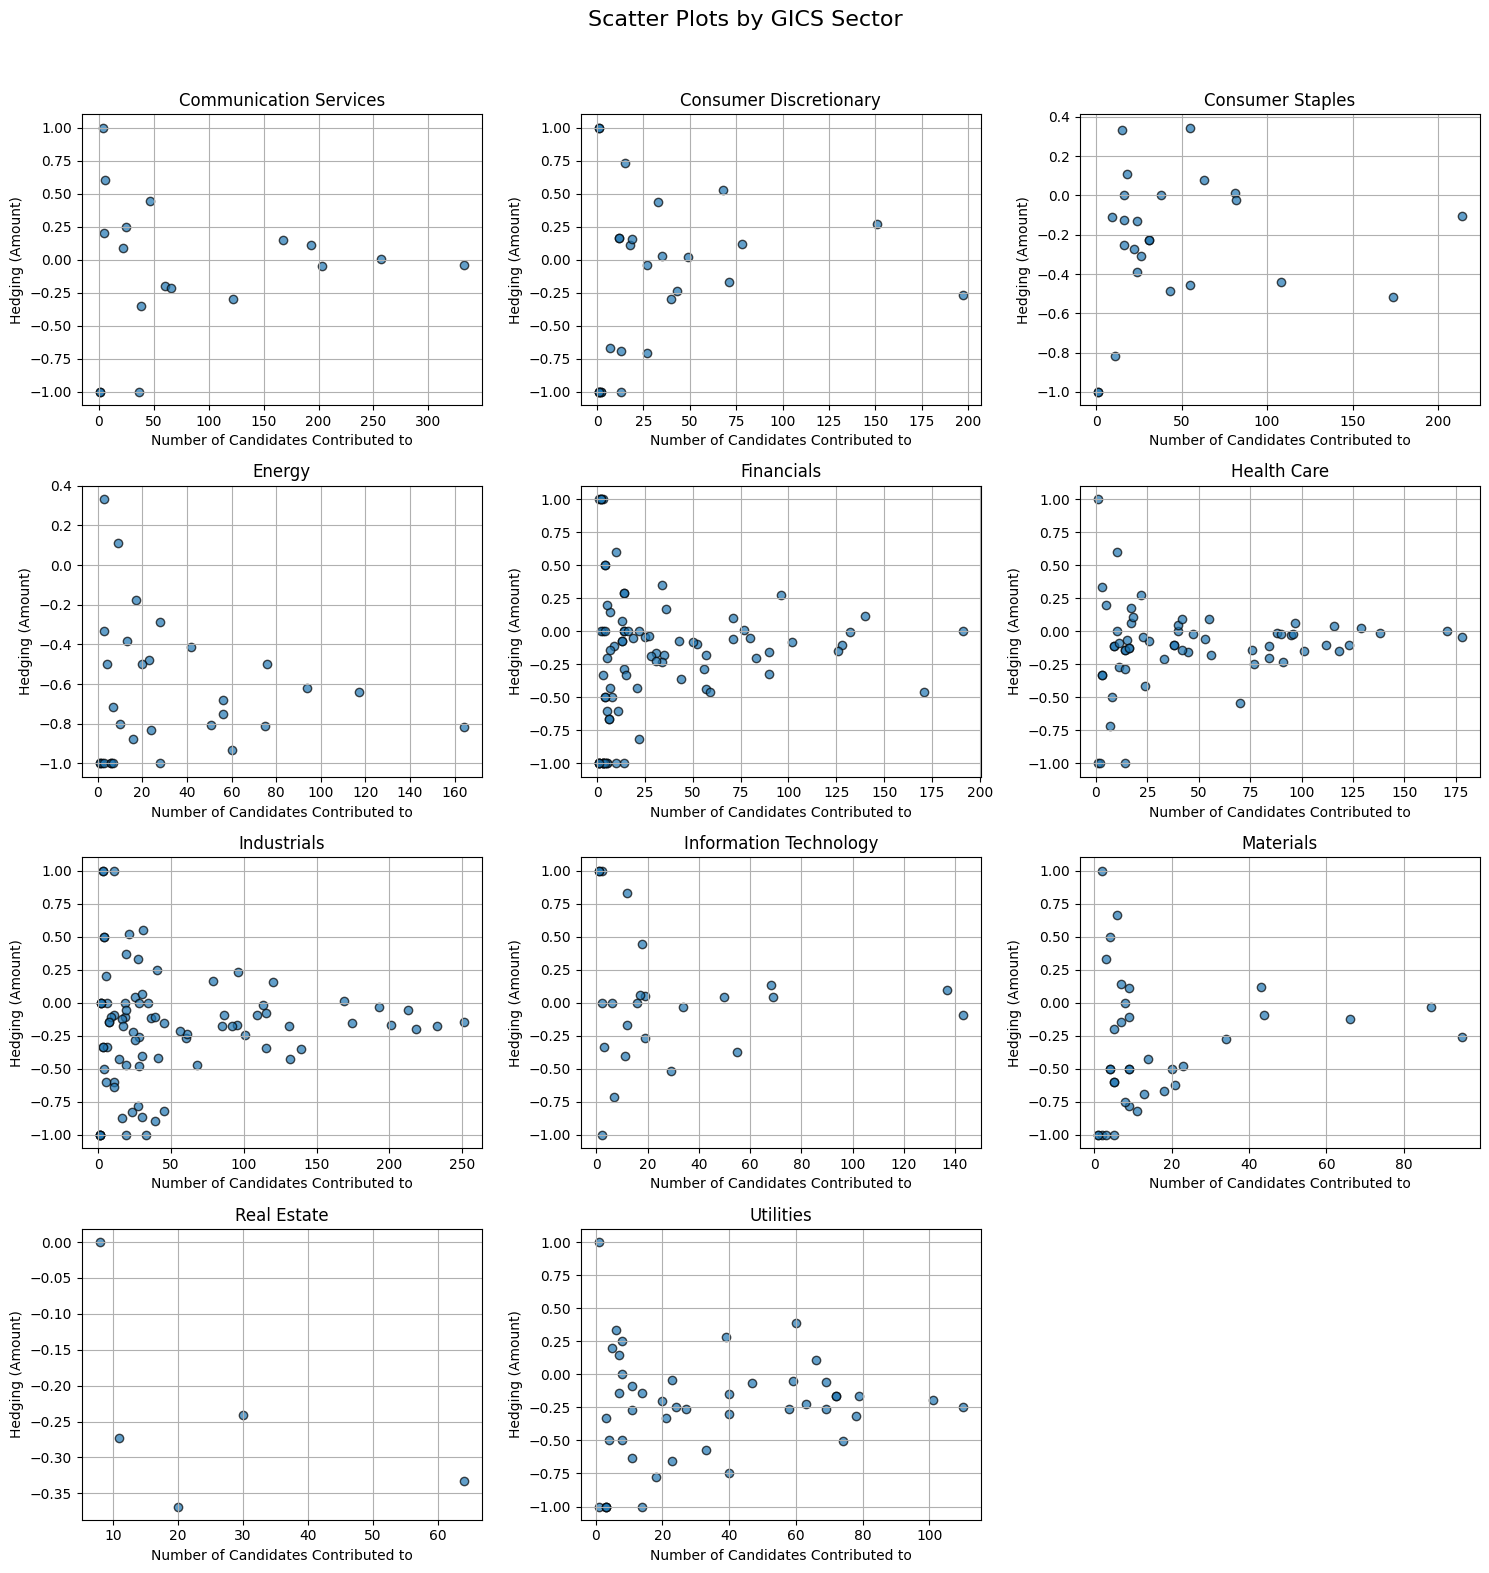

In [388]:
sectors = cpac_hedge_2024['GICS_Sector'].dropna().unique()
sectors.sort()

# Plot layout
plots_per_row = 3
n_plots = len(sectors)
n_rows = math.ceil(n_plots / plots_per_row)

fig, axs = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row * 5, n_rows * 4), squeeze=False)

for i, sector in enumerate(sectors):
    row = i // plots_per_row
    col = i % plots_per_row
    ax = axs[row][col]
    
    subset = cpac_hedge_2024[cpac_hedge_2024['GICS_Sector'] == sector]
    ax.scatter(
        subset['n_cands'],
        subset['balance_count'],
        alpha=0.7,
        edgecolor='k'
    )
    ax.set_title(sector)
    ax.set_xlabel('Number of Candidates Contributed to')
    ax.set_ylabel('Hedging (Amount)')
    ax.grid(True)

# Hide any unused subplots
for j in range(n_plots, n_rows * plots_per_row):
    row, col = divmod(j, plots_per_row)
    axs[row][col].set_visible(False)

plt.suptitle('Scatter Plots by GICS Sector', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # reserve space for title
plt.show()

In [401]:
cpac_contrib_2024 = contrib_2024.loc[contrib_2024["CMTE_ID"].isin(cpac_2024["CMTE_ID"]), ].reset_index(drop=True)

In [402]:
cand_receipts_2024 = cpac_contrib_2024.groupby("CAND_ID").agg(
    {
        "CAND_PTY_AFFILIATION": "first",
        "CAND_OFFICE_ST": "first",
        "CAND_OFFICE_DISTRICT": "first",
        "CAND_OFFICE": "first",
        "TRANSACTION_AMT": "sum",
        "CAND_ICI": "first",
        "CMTE_ID": count_unique
    })

In [583]:
st_count_2024 = pd.crosstab(cpac_contrib_2024["CMTE_ID"], cpac_contrib_2024["CAND_OFFICE_ST"])
st_amt_2024 = pd.pivot_table(cpac_contrib_2024, index="CMTE_ID", columns = "CAND_OFFICE_ST", values = "TRANSACTION_AMT", aggfunc="sum").fillna(0)

In [585]:
def calc_min_hhi(n, k):
    q, r = divmod(n, k)
    parts = [q + 1] * r + [q] * (k - r)
    total = sum(parts)
    proportions = np.array(parts) / total
    return np.sum(proportions ** 2)

def calc_concentrate(row, scale = 1):
    row = row.apply(lambda x: max(1, x / scale) if x != 0 else 0)
    total = int(row.sum())
    
    p = row / total
    observed_hhi = (p ** 2).sum()
    #min_hhi = calc_min_hhi(total, k)

    return round(observed_hhi * np.log(total + 1), 5)

In [586]:
st_count_2024["concentrate_count"] = st_count_2024.apply(calc_concentrate, axis = 1)
st_amt_2024["concentrate_amt"] = st_amt_2024.apply(lambda x: calc_concentrate(x, scale = 1000), axis = 1)

In [587]:
st_count_2024 = st_count_2024.reset_index()
st_amt_2024 = st_amt_2024.reset_index()
st_concentrate = pd.merge(st_count_2024[["CMTE_ID", "concentrate_count"]],
                          st_amt_2024[["CMTE_ID", "concentrate_amt"]],
                          how = "left", on = "CMTE_ID")

In [588]:
cpac_hedge_2024 = cpac_hedge_2024.drop(columns = ["concentrate_count", "concentrate_amt"])

In [589]:
cpac_hedge_2024 = pd.merge(cpac_hedge_2024, st_concentrate, how = "left", on = "CMTE_ID")

In [590]:
cpac_hedge_2024

,CMTE_ID,RIC,PermID,Parent,Website,Instrument,CUSIP,ISIN,Common_Name,Business_Description,...,balance_amount,house_balance_count,house_balance_amount,senate_balance_count,senate_balance_amount,TRANSACTION_AMT,n_states,n_cands,concentrate_count,concentrate_amt
0,C00002790,OLN.N,NaN,NaN,NaN,OLN.N,680665205,US6806652052,Olin Corp,Olin Corporation is a vertically integrated gl...,...,-0.733333,-0.750000,-0.636364,-1.000000,-1.000000,37500.0,9.0,11.0,0.30805,0.48160
1,C00007070,TXN.O,NaN,NaN,NaN,TXN.O,882508104,US8825081040,Texas Instruments Inc,Texas Instruments Incorporated is a global sem...,...,-0.210084,0.000000,-0.213483,-0.142857,-0.200000,64000.0,18.0,34.0,0.48594,0.68639
2,C00007948,WY.N,NaN,NaN,NaN,WY.N,962166104,US9621661043,Weyerhaeuser Co,Weyerhaeuser Company is a real estate investme...,...,-0.212560,-0.272727,-0.166227,-0.750000,-0.714286,217000.0,25.0,64.0,0.24052,0.34006
3,C00008151,FHN.N,NaN,NaN,NaN,FHN.N,320517105,US3205171057,First Horizon Corp,First Horizon Corporation is a regional financ...,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,9300.0,3.0,3.0,0.46210,1.04867
4,C00008474,C.N,NaN,NaN,NaN,C.N,172967424,US1729674242,Citigroup Inc,Citigroup Inc. is a global diversified financi...,...,-0.190000,-0.187500,-0.147541,-0.263158,-0.326316,202000.0,40.0,83.0,0.19745,0.21346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,C00892224,NaN,5071083761,NaN,NaN,5071083761,NaN,NaN,Meitheal Pharmaceuticals Inc,Meitheal Pharmaceuticals Inc. is headquartered...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1088,C00893370,NaN,5059100455,NaN,NaN,5059100455,NaN,NaN,Ursa Major Technologies Inc,Ursa Major Technologies Inc is a United States...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1089,C00893859,NaN,NaN,NaN,https://www.phronesisdc.com/,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1090,C00893933,NaN,5034867214,NaN,NaN,5034867214,NaN,NaN,Fuse Integration Inc,Fuse Integration Inc is a United States-based ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


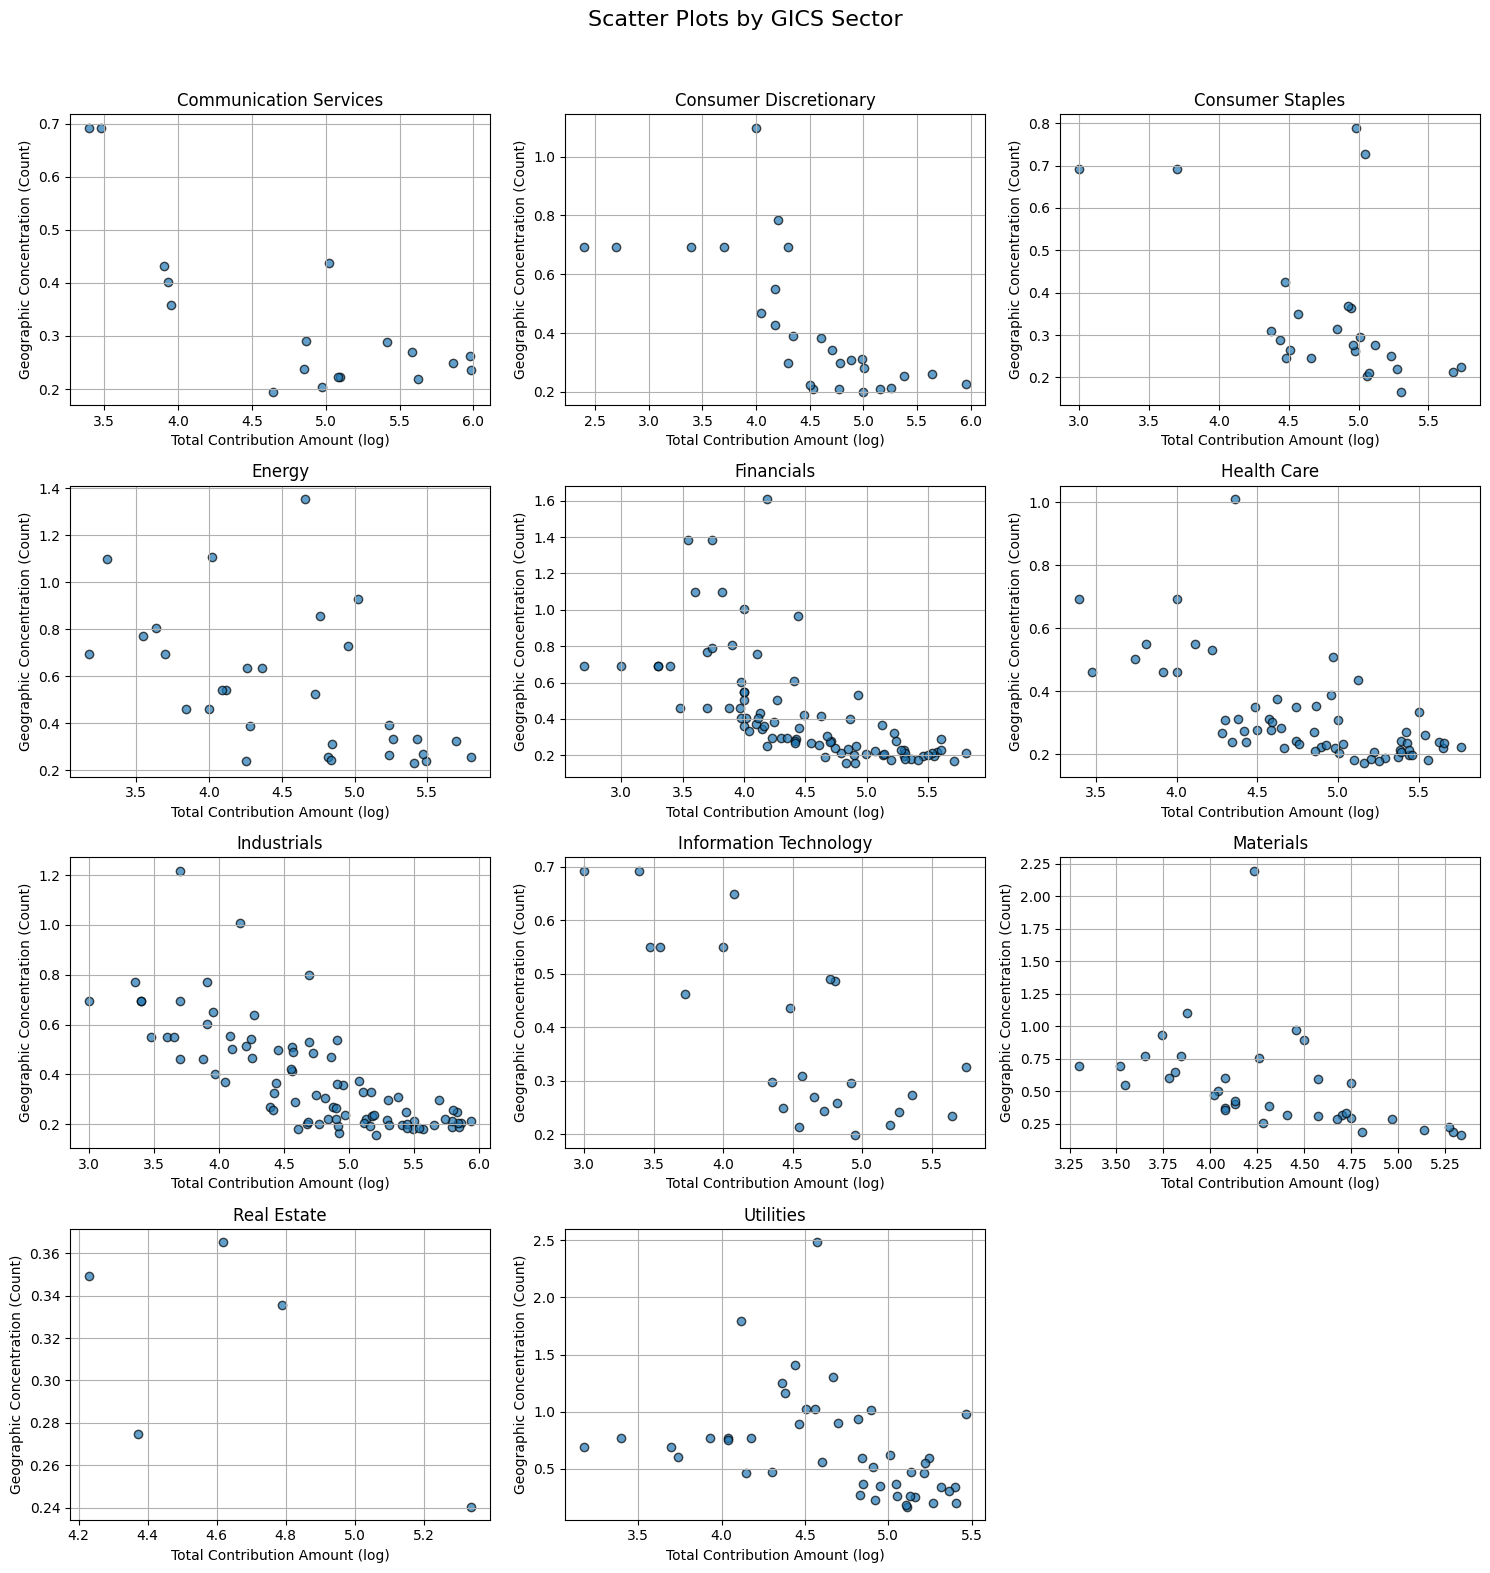

In [598]:
sectors = cpac_hedge_2024['GICS_Sector'].dropna().unique()
sectors.sort()

# Plot layout
plots_per_row = 3
n_plots = len(sectors)
n_rows = math.ceil(n_plots / plots_per_row)

fig, axs = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row * 5, n_rows * 4), squeeze=False)

for i, sector in enumerate(sectors):
    row = i // plots_per_row
    col = i % plots_per_row
    ax = axs[row][col]
    
    subset = cpac_hedge_2024[cpac_hedge_2024['GICS_Sector'] == sector]
    ax.scatter(
        subset['log_amt'],
        subset['concentrate_count'],
        alpha=0.7,
        edgecolor='k'
    )
    ax.set_title(sector)
    ax.set_xlabel('Total Contribution Amount (log)')
    ax.set_ylabel('Geographic Concentration (Count)')
    ax.grid(True)

# Hide any unused subplots
for j in range(n_plots, n_rows * plots_per_row):
    row, col = divmod(j, plots_per_row)
    axs[row][col].set_visible(False)

plt.suptitle('Scatter Plots by GICS Sector', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # reserve space for title
plt.show()

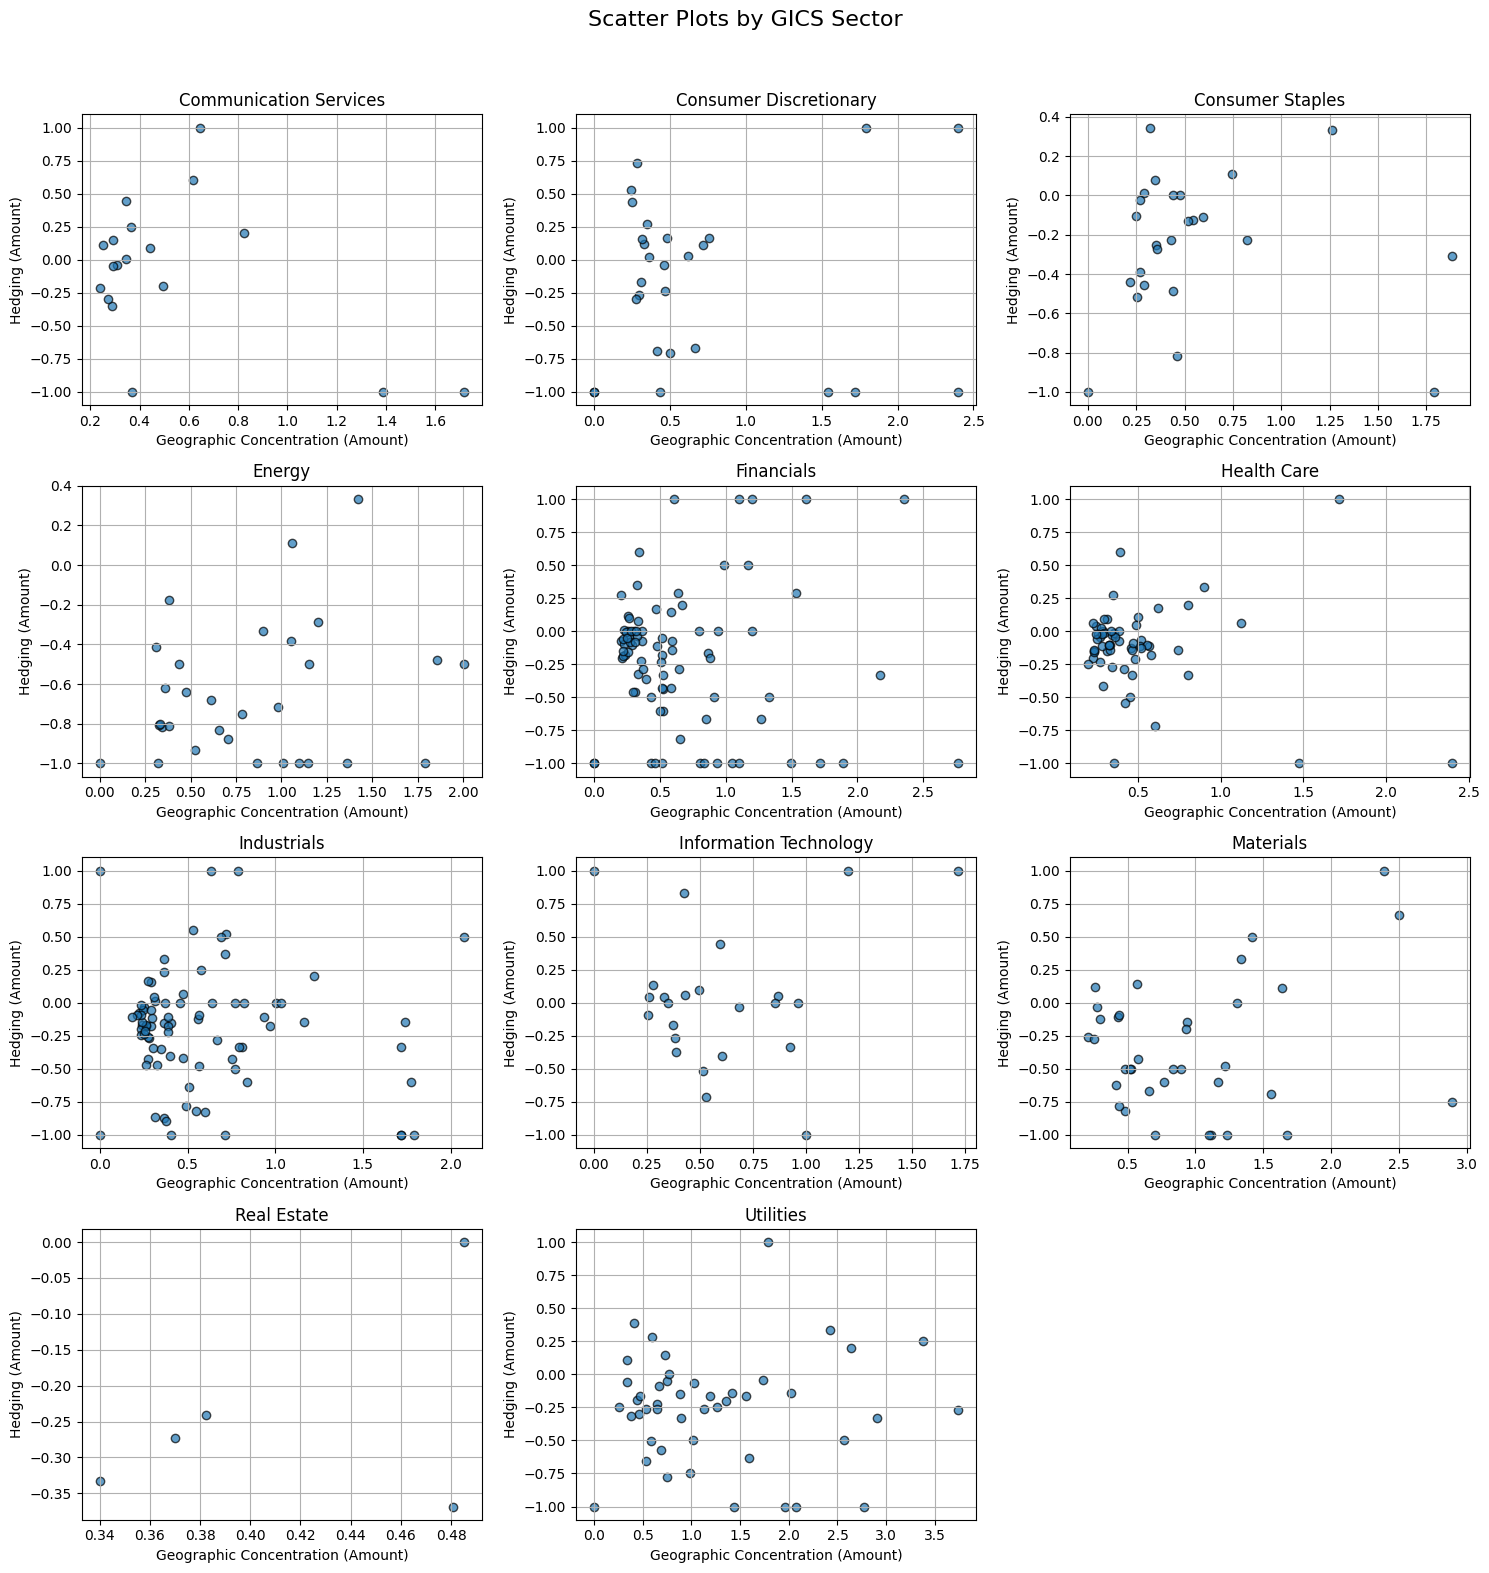

In [563]:
# Plot layout
plots_per_row = 3
n_plots = len(sectors)
n_rows = math.ceil(n_plots / plots_per_row)

fig, axs = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row * 5, n_rows * 4), squeeze=False)

for i, sector in enumerate(sectors):
    row = i // plots_per_row
    col = i % plots_per_row
    ax = axs[row][col]
    
    subset = cpac_hedge_2024[cpac_hedge_2024['GICS_Sector'] == sector]
    ax.scatter(
        subset['concentrate_amt'],
        subset['balance_count'],
        alpha=0.7,
        edgecolor='k'
    )
    ax.set_title(sector)
    ax.set_xlabel('Geographic Concentration (Amount)')
    ax.set_ylabel('Hedging (Amount)')
    ax.grid(True)

# Hide any unused subplots
for j in range(n_plots, n_rows * plots_per_row):
    row, col = divmod(j, plots_per_row)
    axs[row][col].set_visible(False)

plt.suptitle('Scatter Plots by GICS Sector', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # reserve space for title
plt.show()